In [1]:
import numpy as np 
import pandas as pd
import pickle
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path 
import re 
# get utils for thresholds
from src import util_analysis 
from src import util_process_prolific as util_process
import importlib
from tqdm.auto import tqdm
import multiprocessing as mp

/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/scipy/__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


In [2]:
parent_dir = Path("/om/user/imgriff/datasets/human_word_rec_SWC_2024/")
manifest = pd.read_pickle(parent_dir / "full_cue_target_distractor_df_w_meta_paths.pdpkl")

In [3]:
# level = 10* 

## Load participant data and meta files 

In [4]:
### Load in experiment manifests with full transcripts
path_to_manifest = Path('/om/user/imgriff/datasets/human_word_rec_SWC_2024/full_cue_target_distractor_df_w_meta_transcripts.pdpkl')
df_w_transcripts = pd.read_pickle(path_to_manifest)

# unpack distractor words to individual columns

dist_1_word, dist_2_word = zip(*df_w_transcripts.distractor_word.apply(util_process.unpack_dist_words))

df_w_transcripts['distractor_1_word'] = dist_1_word
df_w_transcripts['distractor_2_word'] = dist_2_word
df_w_transcripts['targ_src_stem'] = df_w_transcripts.excerpt_src_fn.apply(util_process.slice_transcript_path)
df_w_transcripts['dist_1_src_stem'] = df_w_transcripts.excerpt_distractor_1_src_fn.apply(util_process.slice_transcript_path)
df_w_transcripts['dist_2_src_stem'] = df_w_transcripts.excerpt_distractor_2_src_fn.apply(util_process.slice_transcript_path)


In [5]:
def get_target_transcript(fname):
    return df_w_transcripts.loc[df_w_transcripts['targ_src_stem'].eq(fname), 'target_transcripts'].values[0]

def get_distractor_tscript(fname):
    if df_w_transcripts['dist_1_src_stem'].eq(fname).any():
        tscript = df_w_transcripts.loc[df_w_transcripts['dist_1_src_stem'].eq(fname), 'distractor_1_transcripts'].values[0]
    elif df_w_transcripts['dist_2_src_stem'].eq(fname).any():
        tscript = df_w_transcripts.loc[df_w_transcripts['dist_2_src_stem'].eq(fname), 'distractor_2_transcripts'].values[0]
    return tscript

In [6]:
importlib.reload(util_process)

path_to_parts = Path('/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/thresholds_v02')

part_results = sorted(list(path_to_parts.glob("*.csv")))

path_to_meta_data = Path('/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/speaker_array_manifests/thresholds_v02/')
meta_files = sorted(list(path_to_meta_data.glob("*meta.pkl")))

# meta_files
manifest_dict = {}
for meta_file in meta_files:
    if 'pilot' in meta_file.parent.stem:
        part_name = "pilot_" + "_".join(meta_file.stem.split('_')[:2])

    else:
        part_name = "_".join(meta_file.stem.split('_')[:2])
    manifest_dict[part_name] = meta_file


dfs = []
for result_file in part_results:
    part_name = result_file.stem
    part_ix = int(re.search(r'(\d+)', part_name).group())
    if part_ix > 33:
        continue
    if any(pilot_part_ix == part_ix for pilot_part_ix in [34, 35]):
        continue 

    # remove space 

    if 'pilot' in result_file.parent.stem:
        part_name = "pilot_" + "_".join(result_file.stem.split('_')[:2])
    if ' ' in part_name:
        part_name = part_name.split(' ')[0]
    # get digits in string pattern participant_xxx_ or participant_XXX. 
    part_ix = int(re.search(r'\d+', part_name).group())
    part_name_str = f"participant_{part_ix:03d}"
    manifest_file = manifest_dict[part_name_str]
    part_df = util_process.get_part_df(result_file)
    manifest_df = util_process.get_manifest_df(manifest_file)
    # merge on shared trial_index
    part_df = pd.merge(part_df[['trial_num', 'response', 'correct_response', 'correct']],
            manifest_df, left_on='trial_num', right_on='trial_num', how='left')
    part_df['participant'] = part_name_str
    dfs.append(part_df)

results_df = pd.concat(dfs, ignore_index=True)

## add transcripts for scoring 
results_df['dist_1_transcripts'] = [util_process.get_distractor_tscript(fname, df_w_transcripts) for fname in results_df.distractor_1_fn.to_list()]
results_df['dist_2_transcripts'] = [util_process.get_distractor_tscript(fname, df_w_transcripts) for fname in results_df.distractor_2_fn.to_list()]
results_df['target_transcripts'] = [util_process.get_target_transcript(fname, df_w_transcripts) for fname in results_df.src_fn.to_list()]

cols_to_score = ['response', 'target_word', 'distractor_1_word', 'distractor_2_word', 'target_transcripts', 'dist_1_transcripts', 'dist_2_transcripts']

## add confusions 
correct = []
confusions = []
for response, target_word, distractor_1_word, distractor_2_word, target_transcripts, dist_1_transcripts, dist_2_transcripts in results_df[cols_to_score].to_numpy():
    correct.append(int(response == target_word or response in target_transcripts))
    confusions.append(int(response in dist_1_transcripts or response in dist_2_transcripts or response in [distractor_1_word, distractor_2_word]))

results_df['correct'] = correct
results_df['confusions'] = confusions




In [8]:
# results_df['sex_condition'] = [util_process.get_array_expmt_sex_cond(row, df_w_transcripts) for idx, row in results_df.iterrows()]
# results_df['sex_condition'] = results_df.sex_condition.apply(lambda x: x[0] if len(x) > 0 else np.nan)

In [9]:
# # get int in participant name 
# results_df['participant_ix'] = results_df.participant.str.extract(r'(\d+)').astype(int)
# results_df.loc[(results_df.azim_delta != 0) & (results_df.participant_ix > 35), 'snr'] = results_df.loc[(results_df.azim_delta != 0) & (results_df.participant_ix > 33), 'snr'] + 3

In [10]:
results_df.columns

Index(['trial_num', 'response', 'correct_response', 'correct', 'target_loc',
       'distractor_loc', 'azim_delta', 'elev_delta', 'snr', 'target_word',
       'distractor_word', 'target_azim', 'target_elev', 'distractor_azim',
       'distractor_elev', 'n_distractors', 'distractor_1_word',
       'distractor_2_word', 'src_fn', 'distractor_1_fn', 'distractor_2_fn',
       'participant', 'dist_1_transcripts', 'dist_2_transcripts',
       'target_transcripts', 'confusions'],
      dtype='object')

## Group data for plots and fitler bad participants

In [11]:
grouped_part_results = results_df.groupby(['participant', 'target_azim', 'target_elev', 'azim_delta', #'sex_condition',
                                   'elev_delta', 'snr', 'n_distractors',]).agg({'correct':['mean', 'sem'],
                                                                                    'confusions':['mean', 'sem', 'count']}).reset_index()
# flatten multiindex
grouped_part_results.columns = ['_'.join(col).strip() for col in grouped_part_results.columns.values]
# remove trailing underscore
grouped_part_results.columns = [col[:-1] if col[-1] == '_' else col for col in grouped_part_results.columns.values]


In [12]:
part_perf_avg = grouped_part_results.groupby('participant').correct_mean.mean()
# filter bad participants as those performing below the lower bound (mean - 2 SEM) seen in the online experiments with the same stimuli
cutoff = 0.3
good_parts = part_perf_avg[(part_perf_avg > cutoff)].index

## Update. Right way to filter: Remove outliers. Compute average performance per participant and make histogram. 
### Make sure average across conditions meets certain threshold.

good_part_results = grouped_part_results[grouped_part_results.participant.isin(good_parts)]

print(f"{good_part_results.participant.nunique()} participants above {cutoff} cutoff (out of {part_perf_avg.shape[0]} total)")

33 participants above 0.3 cutoff (out of 33 total)


In [13]:
good_part_results

,participant,target_azim,target_elev,azim_delta,elev_delta,snr,n_distractors,correct_mean,correct_sem,confusions_mean,confusions_sem,confusions_count
0,participant_001,0,40,0,0,-9,2,0.1875,0.100778,0.1250,0.085391,16
1,participant_001,0,40,0,0,-6,2,0.2500,0.111803,0.1875,0.100778,16
2,participant_001,0,40,0,0,-3,2,0.3125,0.119678,0.2500,0.111803,16
3,participant_001,0,40,0,0,0,2,0.2500,0.111803,0.0625,0.062500,16
4,participant_001,0,40,0,0,3,2,0.7500,0.111803,0.0000,0.000000,16
...,...,...,...,...,...,...,...,...,...,...,...,...
985,participant_033,0,40,60,0,-6,2,0.1875,0.100778,0.3125,0.119678,16
986,participant_033,0,40,60,0,-3,2,0.2500,0.111803,0.1250,0.085391,16
987,participant_033,0,40,60,0,0,2,0.3125,0.119678,0.0625,0.062500,16
988,participant_033,0,40,60,0,3,2,0.6250,0.125000,0.0625,0.062500,16


<Figure size 640x480 with 0 Axes>

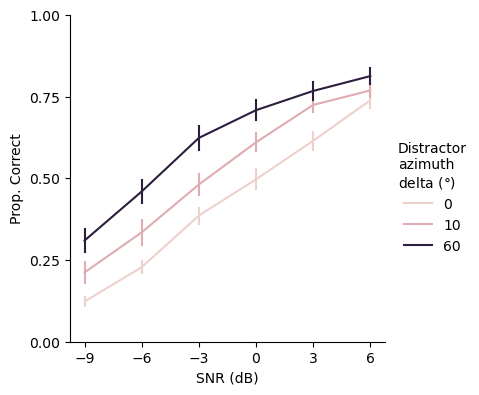

<Figure size 640x480 with 0 Axes>

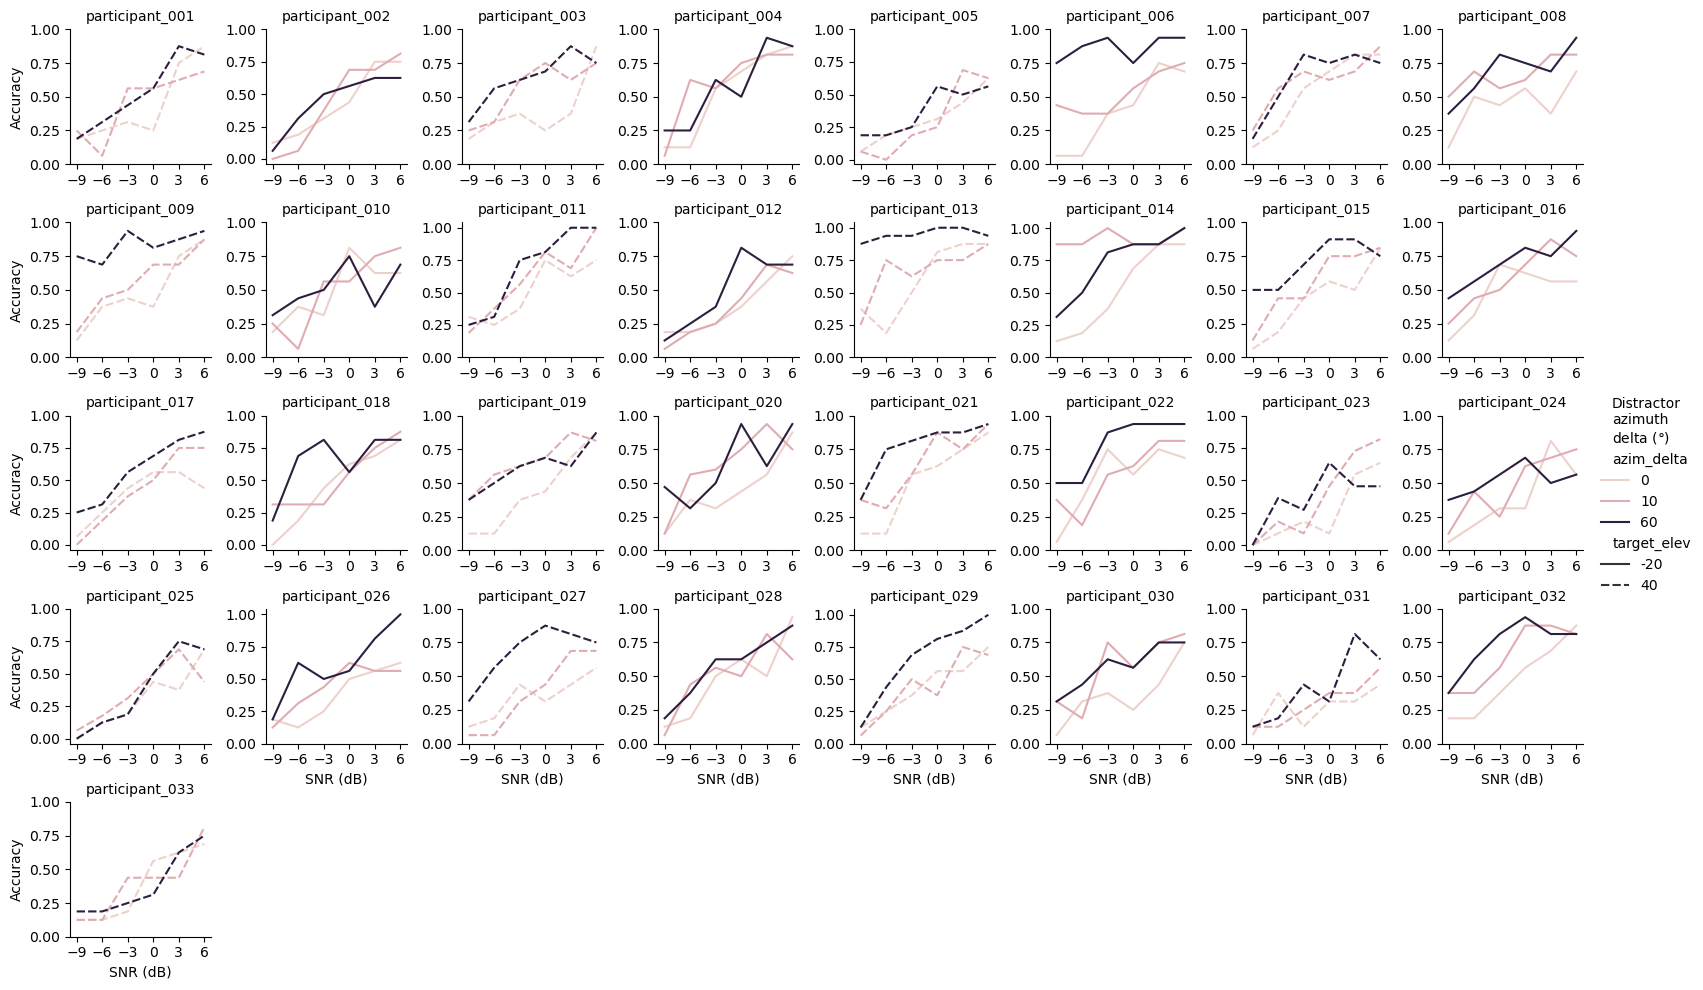

In [14]:
to_plot = good_part_results[
                                        (good_part_results.n_distractors == 2)
                                                #   & (good_part_results.room_str == 'Min. reverb speaker array')
                                                # & (good_part_results.elev_delta.isin([0,10,60]))
                                                &	(good_part_results.elev_delta == 0) 
                                                # &	(good_part_results.target_elev != 0) 
                                            & (good_part_results.azim_delta.abs().isin([0,10, 60]))
                                                #   & (good_part_results.snr.isin([6,3, 0, -3, -6, -9,]))
                                                    ].copy()

# to_plot.distractor_elev = to_plot.distractor_elev.abs()                    
# elev_results_for_thresh = to_plot.groupby(['model','room_str', 'distractor_elev', 'distractor_type', 'snr']).agg({'correct_mean_mean':'mean'}).reset_index()



# elev_thresholds = []
# p0 = [0.0, -4, 4]
# for (model, room, dist_type, elev), group in elev_results_for_thresh.groupby(['model', 'room_str', 'distractor_type', 'distractor_elev']): #, 'gender_cond']):
#     thresh, fit_popt, _ = util_analysis.estimate_thresholds(group.snr.values, group.correct_mean_mean.values, bounds_from_data=True)#, p0=p0)
#     if np.isnan(thresh):
#         print(f"Threshold is nan for elev {elev}")
#     elev_thresholds.append({'model': model, "room":room, "dist_type":dist_type, 'elev': elev, 'threshold':thresh}) #  'gender_cond':gend_cond,
        
# elev_thresh_df = pd.DataFrame(elev_thresholds)
plt.figure()
g = sns.relplot(data=to_plot,
                    x='snr', y='correct_mean', hue="azim_delta",
                    kind='line', legend='full', facet_kws={"sharey":False, "sharex":False},
                    # col='sex_condition',
                    # row='target_elev',
                    # palette=palette, 
                    errorbar=('se', 1),
                    err_style='bars',
                    height=4, aspect=1)
g.set_axis_labels("SNR (dB)", "Prop. Correct")
# set legend title 
new_title = 'Distractor\nazimuth\ndelta ($\degree$)'
g._legend.set_title(new_title)
# set xticks from -9 to 6
g.set(xticks=np.arange(-9, 7, 3), yticks=[0, 0.25, 0.5, 0.75, 1])
# column titles 
g.set_titles("{col_name} {row_name}")
# g.set(title=f'Azimuth trial performance')
plt.figure()
g = sns.relplot(data=to_plot,
                    x='snr', y='correct_mean', hue="azim_delta",
                    kind='line', legend='full', facet_kws={"sharey":False, "sharex":False},
                    col='participant', col_wrap=8,
                    # row='room_str',
                    # palette=palette, 
                    style='target_elev',
                    errorbar=('se', 1),
                    err_style='bars',
                    height=2, aspect=1)
g.set_axis_labels("SNR (dB)", "Accuracy")
# set legend title 
new_title = 'Distractor\nazimuth\ndelta ($\degree$)'
g._legend.set_title(new_title)
# set xticks from -9 to 6
g.set(xticks=np.arange(-9, 7, 3), yticks=[0, 0.25, 0.5, 0.75, 1])
# column titles 
g.set_titles("{col_name}")
# plt.suptitle(f'Model elevation performance', y=1.05)

<Figure size 640x480 with 0 Axes>

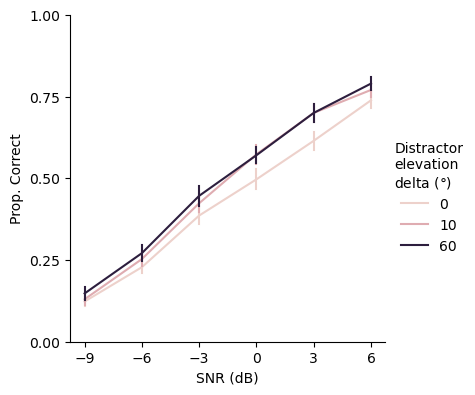

<Figure size 640x480 with 0 Axes>

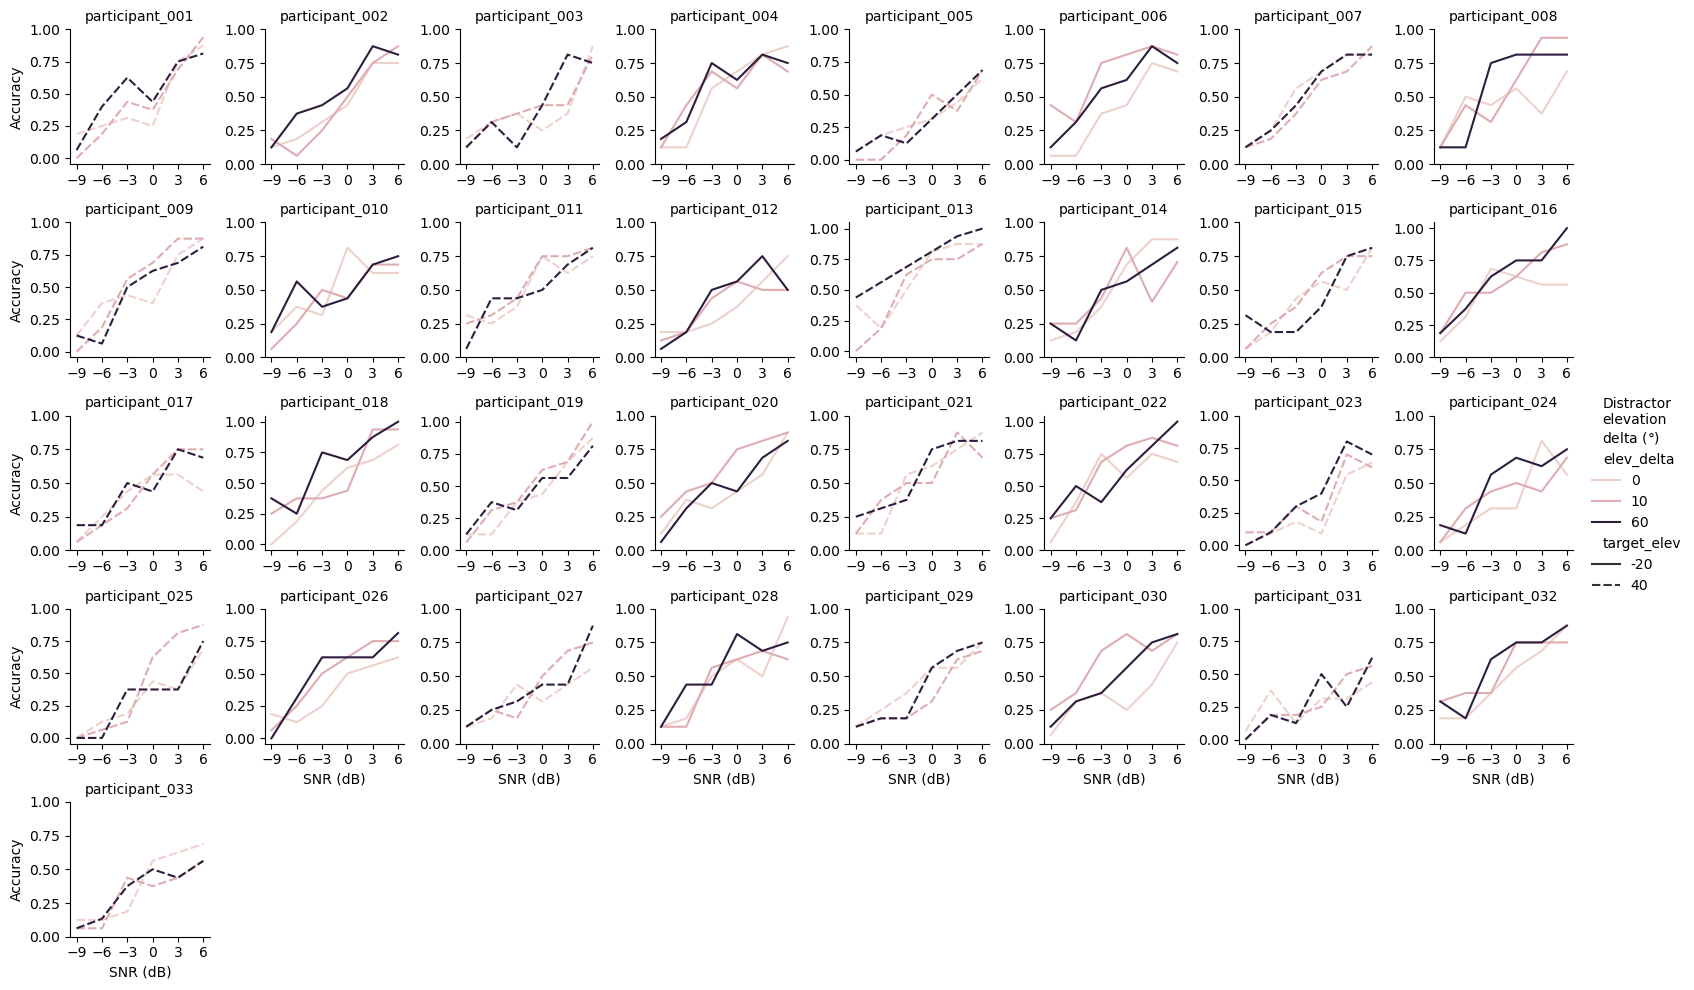

In [15]:
to_plot = good_part_results[
                                        (good_part_results.n_distractors == 2)
                                                #   & (good_part_results.room_str == 'Min. reverb speaker array')
                                                # & (good_part_results.elev_delta.isin([0,10,60]))
                                                &	(good_part_results.azim_delta == 0) 
                                                &	(good_part_results.target_elev != 0) 

                                                #   & (good_part_results.snr.isin([6,3, 0, -3, -6, -9,]))
                                                    ].copy()

# to_plot.distractor_azim = to_plot.distractor_azim.abs()                    
# azim_results_for_thresh = to_plot.groupby(['model','room_str', 'distractor_azim', 'distractor_type', 'snr']).agg({'correct_mean_mean':'mean'}).reset_index()



# azim_thresholds = []
# p0 = [0.0, -4, 4]
# for (model, room, dist_type, azim), group in azim_results_for_thresh.groupby(['model', 'room_str', 'distractor_type', 'distractor_azim']): #, 'gender_cond']):
#     thresh, fit_popt, _ = util_analysis.estimate_thresholds(group.snr.values, group.correct_mean_mean.values, bounds_from_data=True)#, p0=p0)
#     if np.isnan(thresh):
#         print(f"Threshold is nan for azim {azim}")
#     azim_thresholds.append({'model': model, "room":room, "dist_type":dist_type, 'azim': azim, 'threshold':thresh}) #  'gender_cond':gend_cond,
        
# azim_thresh_df = pd.DataFrame(azim_thresholds)
plt.figure()
g = sns.relplot(data=to_plot[to_plot.snr.isin([6,3, 0, -3, -6, -9,])],
                                x='snr', y='correct_mean', hue="elev_delta",
                                kind='line', legend='full', facet_kws={"sharey":False, "sharex":False},
                    # col='sex_condition',
                    # row='target_elev',                                # palette=palette, 
                                errorbar=('se', 1),
                                err_style='bars',
                                height=4, aspect=1)
g.set_axis_labels("SNR (dB)", "Prop. Correct")
# set legend title 
new_title = 'Distractor\nelevation\ndelta ($\degree$)'
g._legend.set_title(new_title)
# set xticks from -9 to 6
g.set_titles("{col_name} ")

g.set(xticks=np.arange(-9, 7, 3), yticks=[0, 0.25, 0.5, 0.75, 1], )#title='Elevation trial performance')
# column titles 
# g.set_titles("{col_name}")
# plt.suptitle(f, y=1.05)
plt.figure()
g = sns.relplot(data=to_plot[to_plot.snr.isin([6,3, 0, -3, -6, -9,])],
                                x='snr', y='correct_mean', hue="elev_delta",
                                kind='line', legend='full', facet_kws={"sharey":False, "sharex":False},
                                col='participant', col_wrap=8,
                                # row='room_str',
                                # palette=palette, 
                                style='target_elev',
                                errorbar=('se', 1),
                                err_style='bars',
                                height=2, aspect=1)
g.set_axis_labels("SNR (dB)", "Accuracy")
# set legend title 
new_title = 'Distractor\nelevation\ndelta ($\degree$)'
g._legend.set_title(new_title)
# set xticks from -9 to 6
g.set(xticks=np.arange(-9, 7, 3), yticks=[0, 0.25, 0.5, 0.75, 1])
# column titles 
g.set_titles("{col_name}")


# Fix threshold esitmation proceedure

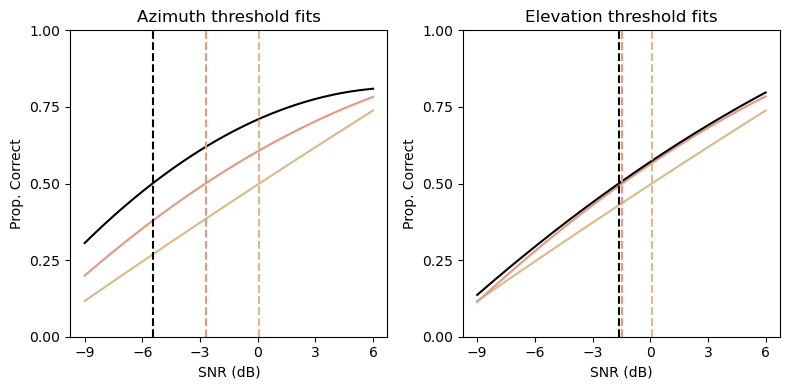

In [16]:
### Update, need to fit polynomial to get threshold instead
## Use 2nd degree polynomial to fit psychometric function.

import scipy 
import numpy as np 
from scipy.optimize import curve_fit
from numpy.polynomial import Polynomial

degree = 2

to_plot = good_part_results[
                        (good_part_results.n_distractors == 2)
                                &	(good_part_results.elev_delta == 0) 
                            & (good_part_results.azim_delta.abs().isin([0,10, 60]))
                                    ].copy()

to_fit = to_plot.groupby(['azim_delta', 'snr']).correct_mean.mean().reset_index()

def fit_threshold_poly(snrs, prop_correct, degree=2):
    poly = Polynomial.fit(x=snrs, y=prop_correct, deg=degree)
    return poly

def get_dBSNR_threshold(poly, threshold=0.5, precision=1_000):
    snrs, prop_correct = poly.linspace(n=precision)
    dB_threshold = snrs[np.argwhere(prop_correct >=threshold).min()]
    return dB_threshold

def estimate_threshold_poly(snrs, prop_correct, degree=2, threshold=0.5):
    poly = fit_threshold_poly(snrs, prop_correct, degree)
    threshold = get_dBSNR_threshold(poly)
    return threshold, poly


to_fit_0 = to_fit[to_fit.azim_delta == 0]
threshold_at_0, poly_at_0 = estimate_threshold_poly(to_fit_0.snr.values, to_fit_0.correct_mean.values, degree)

to_fit_10 = to_fit[to_fit.azim_delta == 10]
threshold_at_10, poly_at_10 = estimate_threshold_poly(to_fit_10.snr.values, to_fit_10.correct_mean.values, degree)

to_fit_60 = to_fit[to_fit.azim_delta == 60]
threshold_at_60, poly_at_60 = estimate_threshold_poly(to_fit_60.snr.values, to_fit_60.correct_mean.values, degree)


to_plot = good_part_results[
                    (good_part_results.n_distractors == 2)
                            #   & (good_part_results.room_str == 'Min. reverb speaker array')
                            # & (good_part_results.elev_delta.isin([0,10,60]))
                            &	(good_part_results.azim_delta == 0) 
                            &	(good_part_results.target_elev != 0) 

                            #   & (good_part_results.snr.isin([6,3, 0, -3, -6, -9,]))
                                ].copy()


to_fit = to_plot.groupby(['elev_delta', 'snr']).correct_mean.mean().reset_index()
# do elev conditions 
to_fit_elev_0 = to_fit[to_fit.elev_delta == 0]
threshold_at_elev_0, poly_at_elev_0 = estimate_threshold_poly(to_fit_elev_0.snr.values, to_fit_elev_0.correct_mean.values, degree)

to_fit_elev_10 = to_fit[to_fit.elev_delta == 10]
threshold_at_elev_10, poly_at_elev_10 = estimate_threshold_poly(to_fit_elev_10.snr.values, to_fit_elev_10.correct_mean.values, degree)

to_fit_elev_60 = to_fit[to_fit.elev_delta == 60]
threshold_at_elev_60, poly_at_elev_60 = estimate_threshold_poly(to_fit_elev_60.snr.values, to_fit_elev_60.correct_mean.values, degree)


fig, axs = plt.subplots(1,2, figsize=(8, 4))
azim_axs = axs[0]
snrs, values = poly_at_0.linspace(n=1000)
azim_axs.plot(snrs, values, 'burlywood', label='0 delta')
snrs, values = poly_at_10.linspace(n=1000)
azim_axs.plot(snrs, values, 'darksalmon', label='10 delta')
snrs, values = poly_at_60.linspace(n=1000)
azim_axs.plot(snrs, values, 'k', label='60 delta');
azim_axs.set_ylim(0,1);
azim_axs.set_xticks(np.arange(-9, 7, 3));
# snrs[np.argmin(np.abs(values - 0.5))]
azim_axs.set_yticks([0, 0.25, 0.5, 0.75, 1])

# fig, elev_axs = plt.subplots(figsize=(4, 4))

elev_axs = axs[1]
snrs, values = poly_at_elev_0.linspace(n=1000)
elev_axs.plot(snrs, values, 'burlywood', label='0 delta')
snrs, values = poly_at_elev_10.linspace(n=1000)
elev_axs.plot(snrs, values, 'darksalmon', label='10 delta')
snrs, values = poly_at_elev_60.linspace(n=1000)
elev_axs.plot(snrs, values, 'k', label='60 delta');
elev_axs.set_ylim(0,1);
elev_axs.set_yticks([0, 0.25, 0.5, 0.75, 1])
elev_axs.set_xticks(np.arange(-9, 7, 3));
# snrs[np.argmin(np.abs(values - 0.5))]


## Add threshold lines
azim_axs.axvline(threshold_at_0, color='burlywood', linestyle='--')
azim_axs.axvline(threshold_at_10, color='darksalmon', linestyle='--')
azim_axs.axvline(threshold_at_60, color='k', linestyle='--')
azim_axs.set_ylabel('Prop. Correct')
azim_axs.set_xlabel('SNR (dB)')
azim_axs.set_title('Azimuth threshold fits')

elev_axs.axvline(threshold_at_elev_0, color='burlywood', linestyle='--')
elev_axs.axvline(threshold_at_elev_10, color='darksalmon', linestyle='--')
elev_axs.axvline(threshold_at_elev_60, color='k', linestyle='--')
elev_axs.set_ylabel('Prop. Correct')
elev_axs.set_xlabel('SNR (dB)')
elev_axs.set_title('Elevation threshold fits')
plt.tight_layout()

## Compute statistics on difference between 0 and 10 degrees and 0 and 60 degrees for human elevation results


## Measure if difference of difference is significant

Compute bootstrapped thresholds to measure true difference of differences:
$d = (t_{10 \text{ azim}} - t_{0 \text{ azim}}) - (t_{10 \text{ elev}} - t_{0 \text{ elev}})$

Then, run permutation test over samples $\hat{d}$ to measure if true $d$ is significant

In [17]:
good_part_results

,participant,target_azim,target_elev,azim_delta,elev_delta,snr,n_distractors,correct_mean,correct_sem,confusions_mean,confusions_sem,confusions_count
0,participant_001,0,40,0,0,-9,2,0.1875,0.100778,0.1250,0.085391,16
1,participant_001,0,40,0,0,-6,2,0.2500,0.111803,0.1875,0.100778,16
2,participant_001,0,40,0,0,-3,2,0.3125,0.119678,0.2500,0.111803,16
3,participant_001,0,40,0,0,0,2,0.2500,0.111803,0.0625,0.062500,16
4,participant_001,0,40,0,0,3,2,0.7500,0.111803,0.0000,0.000000,16
...,...,...,...,...,...,...,...,...,...,...,...,...
985,participant_033,0,40,60,0,-6,2,0.1875,0.100778,0.3125,0.119678,16
986,participant_033,0,40,60,0,-3,2,0.2500,0.111803,0.1250,0.085391,16
987,participant_033,0,40,60,0,0,2,0.3125,0.119678,0.0625,0.062500,16
988,participant_033,0,40,60,0,3,2,0.6250,0.125000,0.0625,0.062500,16


In [18]:
## Bootstrap over participants to get average and confidence intervals over thresholds

np.random.seed(0)
n_boots = 1_000 

N = good_part_results.participant.nunique()
thresholds = []
for (dist_azim, dist_elev), data in good_part_results.groupby(['azim_delta', 'elev_delta']):
    # break
    print(N, data.participant.nunique())
    for _ in tqdm(range(n_boots)):
        # sample with replacement
        participant_sample = np.random.choice(data.participant.unique(), size=N, replace=True)
        # stack sampled participants - this makes sure data is duplicated if resampled 
        sample_data = pd.concat([data[data.participant == part] for part in participant_sample], axis=0, ignore_index=True).reset_index()
        # average participants per SNR 
        sample_data = sample_data.groupby(['snr']).agg({'correct_mean':'mean'}).reset_index()
        # fit to participant average
        thresh, poly= estimate_threshold_poly(sample_data.snr.values, sample_data.correct_mean.values, degree=2)
        thresholds.append({
                    # 'target_elev': target_elev,
                    'azim_delta':dist_azim, 'elev_delta':dist_elev,
                    'threshold':thresh})

human_thresh_df = pd.DataFrame(thresholds)


33 33


  0%|          | 0/1000 [00:00<?, ?it/s]

33 33


  0%|          | 0/1000 [00:00<?, ?it/s]

33 33


  0%|          | 0/1000 [00:00<?, ?it/s]

33 33


  0%|          | 0/1000 [00:00<?, ?it/s]

33 33


  0%|          | 0/1000 [00:00<?, ?it/s]

In [19]:
human_thresh_df.shape

(5000, 3)

In [20]:
# human_thresh_df_summary = human_thresh_df.groupby(['target_elev', 'elev_delta', 'azim_delta', ]).agg({'threshold':['mean', 'std']}).reset_index()
# # flatten multiindex
# human_thresh_df_summary.columns = ['target_elev', 'elev_delta', 'azim_delta', 'threshold', 'threshold_std']

# #

human_thresh_df_summary = human_thresh_df.groupby(['elev_delta', 'azim_delta', ]).agg({'threshold':['mean', 'std']}).reset_index()
# # flatten multiindex
human_thresh_df_summary.columns = ['elev_delta', 'azim_delta', 'threshold', 'threshold_std']

# #

In [21]:
human_thresh_df_summary

,elev_delta,azim_delta,threshold,threshold_std
0,0,0,0.088243,0.508332
1,0,10,-2.733318,0.649656
2,0,60,-5.465495,0.602989
3,10,0,-1.446246,0.495291
4,60,0,-1.595691,0.503478


Text(0.5, 1.0, 'Huamn thresholds (N=33)')

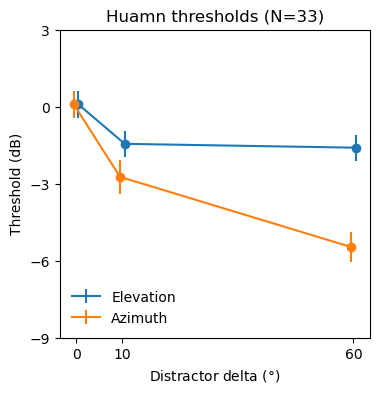

In [22]:
fig, ax = plt.subplots(figsize=(4,4))


elev_data = human_thresh_df_summary[human_thresh_df_summary.azim_delta == 0]
azim_data = human_thresh_df_summary[human_thresh_df_summary.elev_delta == 0]
ax.errorbar(data=elev_data, x=elev_data.elev_delta + 0.5, y='threshold', yerr='threshold_std', fmt='o-', label='Elevation')
ax.errorbar(data=azim_data, x=azim_data.azim_delta - 0.5, y='threshold', yerr='threshold_std', fmt='o-', label='Azimuth')

ax.legend(loc='lower left', markerscale=0)
ax.get_legend().get_frame().set_linewidth(0.0)

ax.set_xlabel('Distractor delta ($\degree$)')
ax.set_ylabel('Threshold (dB)')
ax.set_xticks([0, 10, 60])
ax.set_yticks(np.arange(-9, 5, 3))
ax.set_title(f"Huamn thresholds (N={N})")

### Do it again but within target elevation 

In [22]:
good_part_results

,participant,target_azim,target_elev,azim_delta,elev_delta,snr,n_distractors,correct_mean,correct_sem,confusions_mean,confusions_sem,confusions_count
0,participant_001,0,40,0,0,-9,2,0.1875,0.100778,0.1250,0.085391,16
1,participant_001,0,40,0,0,-6,2,0.2500,0.111803,0.1875,0.100778,16
2,participant_001,0,40,0,0,-3,2,0.3125,0.119678,0.2500,0.111803,16
3,participant_001,0,40,0,0,0,2,0.2500,0.111803,0.0625,0.062500,16
4,participant_001,0,40,0,0,3,2,0.7500,0.111803,0.0000,0.000000,16
...,...,...,...,...,...,...,...,...,...,...,...,...
1135,participant_040,0,-20,60,0,-3,2,0.3750,0.125000,0.0000,0.000000,16
1136,participant_040,0,-20,60,0,0,2,0.8750,0.085391,0.0625,0.062500,16
1137,participant_040,0,-20,60,0,3,2,1.0000,0.000000,0.0000,0.000000,16
1138,participant_040,0,-20,60,0,6,2,0.9375,0.062500,0.0000,0.000000,16


In [23]:
## Bootstrap over participants to get average and confidence intervals over thresholds

np.random.seed(0)
n_boots = 10_000 

# N = good_part_results.participant.nunique()
thresholds = []
for (target_elev, dist_azim, dist_elev), data in good_part_results.groupby(['target_elev', 'azim_delta', 'elev_delta']):
    # break
    N = data.participant.nunique()

    # print(N, data.participant.nunique())

    for _ in tqdm(range(n_boots)):
        # sample with replacement
        participant_sample = np.random.choice(data.participant.unique(), size=N, replace=True)
        # stack sampled participants - this makes sure data is duplicated if resampled 
        sample_data = pd.concat([data[data.participant == part] for part in participant_sample], axis=0, ignore_index=True).reset_index()
        # average participants per SNR 
        sample_data = sample_data.groupby(['snr']).agg({'correct_mean':'mean'}).reset_index()
        # fit to participant average
        thresh, poly= estimate_threshold_poly(sample_data.snr.values, sample_data.correct_mean.values, degree=2)
        thresholds.append({
                    'target_elev': target_elev,
                    'azim_delta':dist_azim, 'elev_delta':dist_elev,
                    'threshold':thresh})

human_elev_sep_thresh_df = pd.DataFrame(thresholds)


  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

In [24]:
# human_elev_sep_thresh_df_summary = human_elev_sep_thresh_df.groupby(['target_elev', 'elev_delta', 'azim_delta', ]).agg({'threshold':['mean', 'std']}).reset_index()
# # flatten multiindex
# human_elev_sep_thresh_df_summary.columns = ['target_elev', 'elev_delta', 'azim_delta', 'threshold', 'threshold_std']

# #

human_elev_sep_thresh_df_summary = human_elev_sep_thresh_df.groupby(['target_elev', 'elev_delta', 'azim_delta', ]).agg({'threshold':['mean', 'std']}).reset_index()
# # flatten multiindex
human_elev_sep_thresh_df_summary.columns = ['target_elev', 'elev_delta', 'azim_delta', 'threshold', 'threshold_std']

# #

Text(0.5, 1.0, 'Huamn thresholds (N=19) \n 19 target elevation')

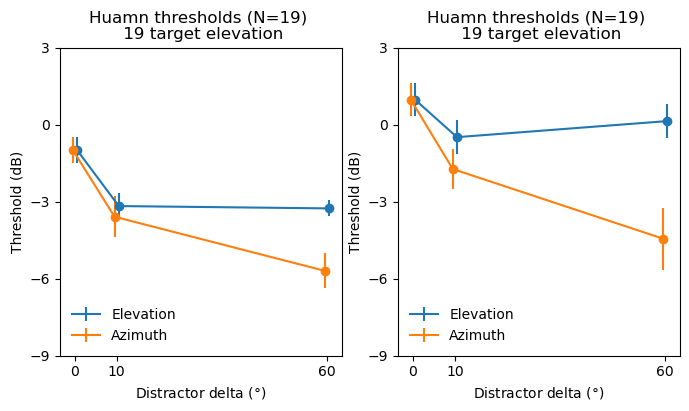

In [25]:
fig, ax = plt.subplots(1,2, figsize=(8,4))
human_20 = human_elev_sep_thresh_df_summary[human_elev_sep_thresh_df_summary.target_elev == -20]
human_40 = human_elev_sep_thresh_df_summary[human_elev_sep_thresh_df_summary.target_elev == 40]

for ix, df_set in enumerate([human_20, human_40]):
    # N = df_set.participant.nunique()

    elev_data = df_set[df_set.azim_delta == 0]
    azim_data = df_set[df_set.elev_delta == 0]
    ax[ix].errorbar(data=elev_data, x=elev_data.elev_delta + 0.5, y='threshold', yerr='threshold_std', fmt='o-', label='Elevation')
    ax[ix].errorbar(data=azim_data, x=azim_data.azim_delta - 0.5, y='threshold', yerr='threshold_std', fmt='o-', label='Azimuth')

    ax[ix].legend(loc='lower left', markerscale=0)
    ax[ix].get_legend().get_frame().set_linewidth(0.0)

    ax[ix].set_xlabel('Distractor delta ($\degree$)')
    ax[ix].set_ylabel('Threshold (dB)')
    ax[ix].set_xticks([0, 10, 60])
    ax[ix].set_yticks(np.arange(-9, 4, 3))
    
ax[0].set_title(f"Huamn thresholds (N={N}) \n {good_part_results[good_part_results.target_elev == -20].participant.nunique()} target elevation")
ax[1].set_title(f"Huamn thresholds (N={N}) \n {good_part_results[good_part_results.target_elev == 40].participant.nunique()} target elevation")

In [74]:
human_thresh_df_summary

,elev_delta,azim_delta,threshold,threshold_std
0,0,0,-0.138263,0.430867
1,0,10,-2.624981,0.553527
2,0,60,-5.236955,0.680565
3,10,0,-1.780508,0.455547
4,60,0,-1.671290,0.498382


In [75]:
### Compute differences   
# elev diffs: 10 - 0 and 60 - 0 
zero_delta_thresh = human_thresh_df_summary[(human_thresh_df_summary.elev_delta == 0) & (human_thresh_df_summary.azim_delta == 0)].threshold.values
elev_data = human_thresh_df_summary[human_thresh_df_summary.azim_delta == 0]
elev_10_diff = elev_data[elev_data.elev_delta == 10].threshold.values - zero_delta_thresh
elev_60_diff = elev_data[elev_data.elev_delta == 60].threshold.values - zero_delta_thresh

# azim diffs: 10-0 and 60-0
azim_data = human_thresh_df_summary[human_thresh_df_summary.elev_delta == 0]
azim_10_diff = azim_data[azim_data.azim_delta == 10].threshold.values - zero_delta_thresh
azim_60_diff = azim_data[azim_data.azim_delta == 60].threshold.values - zero_delta_thresh

# get true difference of differences 
diff_of_diff_at_10 = azim_10_diff - elev_10_diff
diff_of_diff_at_60 = azim_60_diff - elev_60_diff

print(f"difference of differences at 10 degree delta: {diff_of_diff_at_10.item():.5}")
print(f"difference of differences at 60 degree delta: {diff_of_diff_at_60.item():.5}")

difference of differences at 10 degree delta: -0.84447
difference of differences at 60 degree delta: -3.5657


[Text(10, 0, 'Azimuth $-$ Elevation\n $\\Delta t(10^\\circ,0^\\circ)$'),
 Text(30, 0, 'Azimuth $-$ Elevation\n $\\Delta t(60^\\circ,0^\\circ)$')]

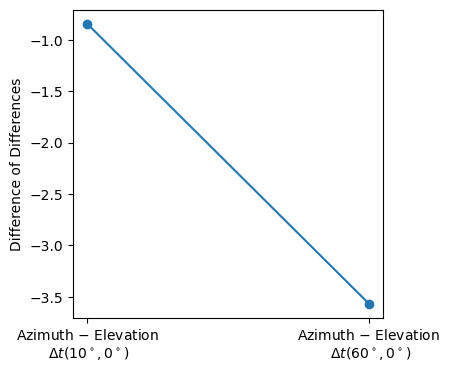

In [76]:
### Plot difference of differences

fig, ax = plt.subplots(figsize=(4,4))
ax.plot([10, 30], [diff_of_diff_at_10, diff_of_diff_at_60], 'o-')
ax.set_ylabel('Difference of Differences')
ax.set_xticks([10 ,30])
x_labels = ["Azimuth $-$ Elevation\n $\Delta t(10^\circ,0^\circ)$", "Azimuth $-$ Elevation\n $\Delta t(60^\circ,0^\circ)$"] 
ax.set_xticklabels(x_labels)


In [77]:
elev_data[elev_data.elev_delta == 10].threshold.values , zero_delta_thresh , elev_10_diff

(array([-1.78050751]), array([-0.13826276]), array([-1.64224474]))

In [57]:
azim_data[azim_data.azim_delta == 10].threshold.values , zero_delta_thresh, azim_10_diff

(array([-2.62498078]), array([-0.13826276]), array([-2.48671802]))

In [29]:
permuted

NameError: name 'permuted' is not defined

In [58]:
### Run bootstrap for true thresholds
## Bootstrap over participants to get average and confidence intervals over thresholds
np.random.seed(0)
n_boots = 10_000 

diff_of_diff_10_dist = np.zeros(n_boots)
diff_of_diff_60_dist =  np.zeros(n_boots)

for ix in tqdm(range(n_boots)):
    # permute distractor elevations and azimuths
    permuted = good_part_results.copy()
    # for delta in [10, 60]:
    for part in permuted.participant.unique():
        permuted.loc[permuted.participant == part, 'elev_delta'] = np.random.permutation(permuted[permuted.participant == part].elev_delta)
        permuted.loc[permuted.participant == part, 'azim_delta'] = np.random.permutation(permuted[permuted.participant == part].azim_delta)
    
    # average over particiapnts 
    permuted_summary = permuted.groupby(['snr', 'elev_delta', 'azim_delta' ]).agg({'correct_mean':'mean'}).reset_index()
    
    # only need to do this once per permutation
    zero_delta = permuted_summary[(permuted_summary.elev_delta == 0) & (permuted_summary.azim_delta == 0)]
    thresh_0, _ = estimate_threshold_poly(zero_delta.snr.values, zero_delta.correct_mean.values, degree=2)

    # get elev delta threshold 
    elev_delta = permuted_summary[(permuted_summary.elev_delta == 10)]
    thresh_elev, _ = estimate_threshold_poly(elev_delta.snr.values, elev_delta.correct_mean.values, degree=2)
    # get azim delta threshold
    azim_delta = permuted_summary[permuted_summary.azim_delta == 10]
    thresh_azim, _ = estimate_threshold_poly(azim_delta.snr.values, azim_delta.correct_mean.values, degree=2)
    # compute difference
    elev_diff = thresh_elev - thresh_0
    azim_diff = thresh_azim - thresh_0
    # compute difference of differences
    diff_of_diff = azim_diff - elev_diff
    diff_of_diff_10_dist[ix] = diff_of_diff

    #  repeat for 60 degree delta
    elev_delta = permuted_summary[(permuted_summary.elev_delta == 60)]
    thresh_elev, _ = estimate_threshold_poly(elev_delta.snr.values, elev_delta.correct_mean.values, degree=2)
    # get azim delta threshold
    azim_delta = permuted_summary[permuted_summary.azim_delta == 60]
    thresh_azim, _ = estimate_threshold_poly(azim_delta.snr.values, azim_delta.correct_mean.values, degree=2)
    # compute difference
    elev_diff = thresh_elev - thresh_0
    azim_diff = thresh_azim - thresh_0
    # compute difference of differences
    diff_of_diff = azim_diff - elev_diff
    diff_of_diff_60_dist[ix] = diff_of_diff


  0%|          | 0/10000 [00:00<?, ?it/s]

In [78]:
(np.abs(diff_of_diff_10_dist) > np.abs(diff_of_diff_at_10)).sum()

751

In [79]:
### Get p value for difference of differences at 10 and 60 degrees

p_10 = (np.abs(diff_of_diff_10_dist) > np.abs(diff_of_diff_at_10)).mean()
p_60 = (np.abs(diff_of_diff_60_dist) > np.abs(diff_of_diff_at_60)).mean()

print(f"p value for difference of differences at 10 degrees: {p_10:.4}")
print(f"p value for difference of differences at 60 degrees: {p_60:.4}")

p value for difference of differences at 10 degrees: 0.0751
p value for difference of differences at 60 degrees: 0.0


In [80]:
np.abs(diff_of_diff_10_dist).max(), np.abs(diff_of_diff_at_10)

(2.0240240240240244, array([0.84447327]))

In [104]:
np.abs(diff_of_diff_60_dist).max(), np.abs(diff_of_diff_at_60)

NameError: name 'diff_of_diff_60_dist' is not defined

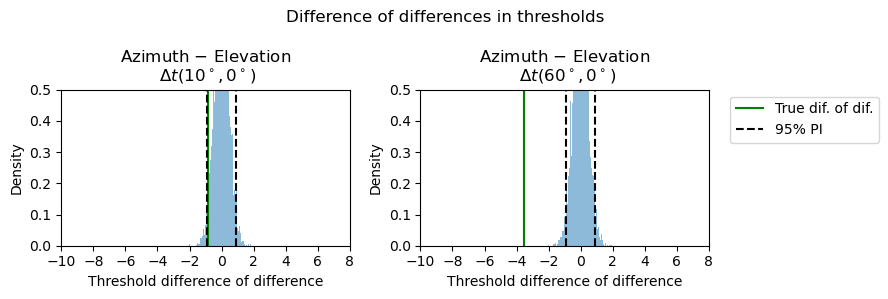

In [82]:
## Plot histograms per SNR with actual differences as v lines 
# each SNR as a subplot
fig, axs = plt.subplots(1, 2, figsize=(9, 3))
ax = axs[0]
ax.hist(diff_of_diff_10_dist, bins=100, alpha=0.5, density=True)
ax.axvline(diff_of_diff_at_10, color='g',)
ax.set_title("Azimuth $-$ Elevation\n $\Delta t(10^\circ,0^\circ)$")

# add vline for significance
ax.axvline(np.percentile(diff_of_diff_10_dist, 2.5,), color='k', linestyle='--')
ax.axvline(np.percentile(diff_of_diff_10_dist, 97.5,), color='k', linestyle='--', label='95% PI')

ax2 = axs[1]
ax2.hist(diff_of_diff_60_dist, bins=100, alpha=0.5,  density=True)
ax2.axvline(diff_of_diff_at_60, color='g', label='True dif. of dif.')
# add vline for significance
ax2.axvline(np.percentile(diff_of_diff_60_dist, 2.5,), color='k', linestyle='--')
ax2.axvline(np.percentile(diff_of_diff_60_dist, 97.5,), color='k', linestyle='--', label='95% PI')
ax2.set_title("Azimuth $-$ Elevation\n $\Delta t(60^\circ,0^\circ)$")
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.suptitle("Difference of differences in thresholds")

for ax in axs:
    ax.set_xlabel("Threshold difference of difference")
    ax.set_ylabel("Density")
    ax.set_ylim(0, 0.5)
    ax.set_xticks(np.arange(-10, 10, 2))
    # ax.set_xlim(-7, 7)
plt.tight_layout()

## Load model data and meta files

In [23]:
room_manifest = pd.read_pickle('/om2/user/msaddler/spatial_audio_pipeline/assets/brir/eval/manifest_room.pdpkl')
# for tuple_ in room_manifest.itertuples():
#     print(tuple_)
#     break
room_material_map = {}
for row in room_manifest.itertuples():
    wall1 = row.material_x0[0].split(',')[0]
    wall2 = row.material_y1[0].split(',')[0]
    if wall1 == wall2:
        wall_str = f"{wall1} walls"
    else:
        wall_str = f"{wall1} and {wall2} walls"

    floor = row.material_z0[0].split(',')[0]
    ceiling = row.material_z1[0].split(',')[0]
    name_str = f"{wall_str} \n {floor} floor \n {ceiling} ceiling"

    if row.index_room in [5, 6]:
        name_str = 'Alternate speaker room'
    if row.index_room in [6, 8]:
        name_str += ' \n head rotated'
    else:
        head_rotated = ''
    if 'Anechoic' in name_str:
        name_str = "Anechoic"
    room_material_map[row.index_room] = name_str
# room_material_map = {row.index_room: f"{row.material_x0[0].split(',')[0]} and \n {row.material_y1[0].split(',')[0]} walls \n {row.material_z0[0].split(',')[0]} floor \n {row.material_z1[0].split(',')[0]} ceiling" for row in room_manifest.itertuples()}
# room_material_map[5] = 'standard speaker room'
room_material_map

{0: 'Anechoic',
 1: 'Wood panelling on glass fiber blanket walls \n Carpet on foam rubber padding floor \n Highly absorptive panels ceiling',
 2: 'Brick walls \n Wood parquet on concrete floor \n Plaster ceiling',
 3: 'Fiberglass wall treatment walls \n Linoleum floor \n Acoustic tiles ceiling',
 4: 'Concrete walls \n Linoleum floor \n Acoustic tiles ceiling',
 5: 'Alternate speaker room',
 6: 'Alternate speaker room \n head rotated',
 7: 'Fiberglass wall treatment walls \n Linoleum floor \n Acoustic tiles ceiling',
 8: 'Fiberglass wall treatment walls \n Linoleum floor \n Acoustic tiles ceiling \n head rotated'}

In [24]:
import pickle 

# manifest_path = "binaural_test_manifests/sim_2024_human_experiment.pkl"
manifest_path = "binaural_test_manifests/symmetric_distractor_conditions_w_front_back_neg_21_to_6_dBSNR_min_reverb_mit_room.pkl"
with open(manifest_path, "rb") as f: 
    manifest = pickle.load(f)
    

In [25]:
manifest_df  = pd.DataFrame(manifest.values())
# manifest_df

In [26]:
# spkr_room_manifest = pd.read_pickle('/om2/user/msaddler/spatial_audio_pipeline/assets/brir/mit_bldg46room1004/manifest_room.pdpkl')
spkr_room_manifest = pd.read_pickle('/om2/user/imgriff/spatial_audio_pipeline/assets/brir/mit_bldg46room1004_min_reverb/manifest_room.pdpkl')

In [27]:
# Path to results 
# output_paths = list(Path("binaural_eval/word_task_voice_loc_cue_only_v04").glob("*.pkl")) old path for more locations

# match human pilot conditions
# model_name = 'word_task_half_co_loc_v06'
# output_paths = list(Path(f"binaural_eval/simulate_2024_human_array_experiment/").glob("*/*room*.pkl"))

output_paths = list(Path(f"binaural_eval/simulate_2024_human_array_experiment_v02/").glob("*/*.pkl"))
# output_paths.extend(list(Path(f"binaural_eval/simulate_2024_human_array_experiment_white_noise_dist/").glob("*/*.pkl")))
# output_paths.append(list(Path(f"binaural_eval/texture_srm_experiment/").glob("*/*.pkl")))

stim_manifest_df = pd.read_pickle('/om/user/imgriff/datasets/human_word_rec_SWC_2024/full_cue_target_distractor_df_w_meta.pdpkl')

## Get anechoic room for comparison 
# output_paths += list(Path(f"binaural_eval/symmetric_distractor_test/").glob("*/*eval*room0000.pkl"))
# anech_stim_manifest_df = pd.read_pickle('/om2/user/rphess/Auditory-Attention/final_binaural_manifest.pkl')
 
word_class_map = pickle.load( open("/om2/user/imgriff/datasets/commonvoice_9/en/cv_800_word_label_to_int_dict.pkl", "rb" )) 
ix_to_word = {v:k for k,v in word_class_map.items()}

remap_azim = lambda azim: 360 - azim if azim > 180 else 0 - azim 

results_dfs = []

wanted_models = ['word_task_half_co_loc_v09_gender_bal_4M_w_no_cue_learned_higher_lr_less_dropout',
                 'word_task_v09_4MGB_ln_first_arch_1',
                'word_task_v09_4MGB_ln_first_arch_2',
                'word_task_v09_4MGB_ln_first_arch_4',
                'word_task_v09_4MGB_ln_first_arch_6',
                'word_task_v09_4MGB_ln_first_arch_7',
                'word_task_v09_4MGB_ln_first_arch_8',
                'word_task_v09_4MGB_ln_first_arch_9',
]


gend_map = {True:'same', False:'different'}

for path in output_paths:
    if not any([model in path.stem for model in wanted_models]):
        continue
    if not 'v09' in str(path):
        continue
    if 'modulated' in path.stem:
        continue 
    # if not 'mitb46' in path.stem:
    #     continue 
    if 'white_noise' in path.as_posix():
        continue
    if 'texture' in path.as_posix():
        continue

    res_dict = pickle.load(open(path, 'rb'))
    df = pd.DataFrame.from_dict(res_dict)
    # break
    df.rename(columns={"results": "accuracy"}, inplace=True)
    df['model'] = path.parent.stem

    # if not 'min' in path.stem: 
    #     df = df.join(anech_stim_manifest_df[['word', 'bg_word','gender', 'bg_gender']], how='outer')
    #     df.rename(columns={'bg_word':"distractor_word"}, inplace=True)  
    #     df['sex_cond'] = df["gender"].values == df['bg_gender'].values
    #     df['sex_cond'] =  df['sex_cond'].map(gend_map)
    # else:
    # # # merge with stim manifest
    df.loc[df.index.values, ['word', 'distractor_word','sex_cond']] = stim_manifest_df.loc[df.stim_ix_list.values, ['word', 'distractor_word','sex_cond']].values
    df['target_word'] = df['true_word_int'].map(ix_to_word)
    df['pred_word'] = df['preds'].map(ix_to_word)
    df['correct'] = (df['true_word_int'] == df['preds']).astype('int')
    df['str_confusions'] = df[['pred_word', 'distractor_word']].apply(lambda x: 1 if x.pred_word in x.distractor_word else 0, axis=1)
    if 'clean' in path.stem:
        snr = 'clean'
    else:
        snr = int(re.search('(-?\d+)_SNR', path.stem).group(0).strip('_SNR'))
        
    df['snr'] = snr 
    df["target_azim"], df["target_elev"] = path.stem.split('target_loc_')[1].split('_distract_loc_')[0].split('_')
    df["distractor_azim"], df["distractor_elev"] = path.stem.split('_distract_loc_')[1].split('_')[:2]
    # # map azim to 0-180
    df['target_azim'] = df['target_azim'].astype(int).apply(remap_azim)
    df['distractor_azim'] = df['distractor_azim'].astype(int).apply(remap_azim)
    df['target_elev'] = df['target_elev'].astype(int)
    df['distractor_elev'] = df['distractor_elev'].astype(int)
    df['room_ix'] = int(re.search('room(-?\d+)', path.stem).group(0).strip('room'))
    df['room_type'] = re.search('SNR_(.*?)_room', path.stem).group(0).split('SNR_')[-1].split("_room")[0]
    df['n_distractors'] = 1 if '1_distractor' in path.stem else 2
    df['test_set'] = 'all_stim' if 'all_stim' in path.stem else 'subset'
    if 'white_noise' in path.as_posix():
        df['distractor_type'] = 'white_noise'
    elif 'texture' in path.as_posix():
        df['distractor_type'] = 'texture'
    else:
        df['distractor_type'] = 'speech'
    results_dfs.append(df)

results = pd.concat(results_dfs)

In [28]:
results.room_type.unique()

array(['speech_distractor_min_reverb', 'speech_distractor_eval',
       'speech_distractor_mitb46'], dtype=object)

In [29]:
results.loc[results.room_type.str.contains('eval'), 'room_str'] = results.loc[results.room_type == 'eval', 'room_ix'].map(room_material_map)

results.loc[results.room_type.str.contains('mitb46'), 'room_str'] = 'Normal speaker array'
results.loc[results.room_type.str.contains('mitb46'), 'room_ix'] = 9 # use n from diff room notebook

results.loc[results.room_type.str.contains('reverb'), 'room_str'] = 'Min. reverb speaker array'
results.loc[results.room_type.str.contains('reverb'), 'room_ix'] = 10 # use n from diff room notebook

In [30]:
# results[(results.target_azim == results.distractor_azim) & (results.target_elev != results.distractor_elev)]

In [31]:
grouped_model_results = results.groupby(['model', 'target_azim', 'target_elev', 'distractor_azim', 'test_set', 'distractor_type',
                                   'distractor_elev', 'sex_cond', 'snr', 'n_distractors', 'room_str']).agg({'accuracy':['mean', 'sem'],
                                                                                                                     'confusions':['mean', 'sem']}).reset_index()
# flatten multiindex
grouped_model_results.columns = ['_'.join(col).strip() for col in grouped_model_results.columns.values]
# remove trailing underscore
grouped_model_results.columns = [col[:-1] if col[-1] == '_' else col for col in grouped_model_results.columns.values]



In [32]:
grouped_model_results['distractor_elev_delta'] = (grouped_model_results['target_elev'] - grouped_model_results['distractor_elev']).abs()

In [33]:
grouped_model_results.model.unique()

array(['word_task_half_co_loc_v09_gender_bal_4M_w_no_cue_learned_higher_lr_less_dropout',
       'word_task_v09_4MGB_ln_first_arch_1',
       'word_task_v09_4MGB_ln_first_arch_2',
       'word_task_v09_4MGB_ln_first_arch_4',
       'word_task_v09_4MGB_ln_first_arch_6',
       'word_task_v09_4MGB_ln_first_arch_7',
       'word_task_v09_4MGB_ln_first_arch_8',
       'word_task_v09_4MGB_ln_first_arch_9'], dtype=object)

In [34]:
# put humans and model in same dataframe. Change correct to accuracy in column names 
grouped_model_results.rename(columns={'accuracy_mean':'correct_mean', 'accuracy_sem':'correct_sem',}, inplace=True)
good_part_results.rename(columns={'azim_delta':'distractor_azim', 'elev_delta':'distractor_elev_delta'}, inplace=True)
# grouped_model_results['group'] = grouped_model_results['model']

# get fba model
### merge arch search with main model
wanted_models = ['word_task_half_co_loc_v09_gender_bal_4M_w_no_cue_learned_higher_lr_less_dropout',
                 'word_task_v09_4MGB_ln_first_arch_1',
                'word_task_v09_4MGB_ln_first_arch_2',
                'word_task_v09_4MGB_ln_first_arch_4',
                'word_task_v09_4MGB_ln_first_arch_6',
                'word_task_v09_4MGB_ln_first_arch_7',
                'word_task_v09_4MGB_ln_first_arch_8',
                'word_task_v09_4MGB_ln_first_arch_9',
]
models_to_merge = grouped_model_results[grouped_model_results.model.isin(wanted_models) & (grouped_model_results.room_str == 'Min. reverb speaker array')].copy()
merged_fba_model = models_to_merge.groupby(['target_azim', 'target_elev', 'distractor_azim', 'distractor_elev', 'distractor_elev_delta', 'snr', "sex_cond", 'n_distractors', 'room_str']).agg({'correct_mean':['mean', 'sem']}).reset_index()
merged_fba_model.columns = ['target_azim', 'target_elev', 'distractor_azim', 'distractor_elev', 'distractor_elev_delta', 'snr', 'sex_cond', 'n_distractors', 'room_str', 'correct_mean', 'correct_sem']
merged_fba_model['group'] = 'Feature-gain model'

# get all other models 
control_models = grouped_model_results[~grouped_model_results.model.isin(wanted_models)].copy()
control_models['group'] = control_models.model.map(util_analysis.model_name_dict)


N = good_part_results.participant.nunique()
good_part_results['group'] = f'Humans (N={N})'
# merged_results = pd.concat([grouped_model_results, good_part_results], ignore_index=True, axis=0)
merged_results = pd.concat([control_models, merged_fba_model, good_part_results], ignore_index=True, axis=0)


# N = good_part_results.participant.nunique()
# good_part_results['group'] = f'Humans (N={N})'


# merged_good_parts = merged_results[merged_results.participant.isin(good_parts)]

In [35]:
merged_fba_model

,target_azim,target_elev,distractor_azim,distractor_elev,distractor_elev_delta,snr,sex_cond,n_distractors,room_str,correct_mean,correct_sem,group
0,0,-20,-180,-20,0,-21,different,2,Min. reverb speaker array,0.014472,0.001467,Feature-gain model
1,0,-20,-180,-20,0,-21,same,2,Min. reverb speaker array,0.005379,0.000605,Feature-gain model
2,0,-20,-180,-20,0,-18,different,2,Min. reverb speaker array,0.029841,0.001415,Feature-gain model
3,0,-20,-180,-20,0,-18,same,2,Min. reverb speaker array,0.014344,0.001129,Feature-gain model
4,0,-20,-180,-20,0,-15,different,2,Min. reverb speaker array,0.055840,0.004139,Feature-gain model
...,...,...,...,...,...,...,...,...,...,...,...,...
813,0,40,0,40,0,0,same,2,Min. reverb speaker array,0.315190,0.008814,Feature-gain model
814,0,40,0,40,0,3,different,2,Min. reverb speaker array,0.518571,0.010388,Feature-gain model
815,0,40,0,40,0,3,same,2,Min. reverb speaker array,0.422515,0.012214,Feature-gain model
816,0,40,0,40,0,6,different,2,Min. reverb speaker array,0.599385,0.009968,Feature-gain model


Text(0.5, 1.05, 'Azimuth performance')

<Figure size 640x480 with 0 Axes>

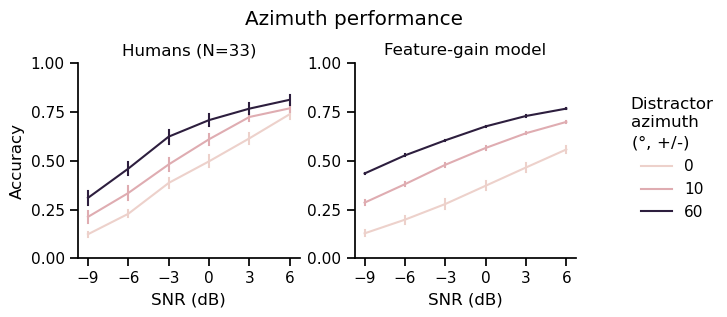

In [36]:


## First, get grand average. Then bootstrap for error 
sns.set_context('notebook')

# avg threshold estimates for 0 and 10 azimuth separation 
to_plot = merged_results[
                                        # (merged_results.n_distractors == 2)
                                                #   & (merged_results.room_str == 'Min. reverb speaker array')
                                                (merged_results.distractor_elev_delta.eq(0 ))
                                                 & (merged_results.distractor_azim.abs().isin([0,10, 60])) 
                                                #   & (merged_results.snr.isin([6,3, 0, -3, -6, -9,]))
                                                    ].copy()

to_plot.distractor_azim = to_plot.distractor_azim.abs()                    
azim_results_for_thresh = to_plot.groupby(['model','room_str', 'distractor_azim', 'distractor_type', 'snr']).agg({'correct_mean':'mean'}).reset_index()



azim_thresholds = []
# p0 = [0.0, -4, 4]
# for (model, room, dist_type, azim), group in azim_results_for_thresh.groupby(['model', 'room_str', 'distractor_type', 'distractor_azim']): #, 'gender_cond']):
#     thresh, fit_popt, _ = util_analysis.estimate_thresholds(group.snr.values, group.correct_mean.values, bounds_from_data=True)#, p0=p0)
#     if np.isnan(thresh):
#         print(f"Threshold is nan for azim {azim}")
#     azim_thresholds.append({'model': model, "room":room, "dist_type":dist_type, 'azim': azim, 'threshold':thresh}) #  'gender_cond':gend_cond,
        
# azim_thresh_df = pd.DataFrame(azim_thresholds)

col_order = [f'Humans (N={N})', "Feature-gain model"]

plt.figure()
g = sns.relplot(data=to_plot[to_plot.snr.isin([6,3, 0, -3, -6, -9,])],
                                x='snr', y='correct_mean', hue="distractor_azim",
                                kind='line', legend='full', facet_kws={"sharey":False, "sharex":False},
                                col='group', col_order=col_order,
                                # row='room_str',
                                # palette=palette, 
                                errorbar=('se', 1),
                                err_style='bars',
                                height=3, aspect=1)

g.set_axis_labels("SNR (dB)", "Accuracy")
# set legend title 
new_title = 'Distractor\nazimuth\n($\degree$, +/-)'
g._legend.set_title(new_title)
# set xticks from -9 to 6
g.set(xticks=np.arange(-9, 7, 3), yticks=[0, 0.25, 0.5, 0.75, 1])
# column titles 
g.set_titles("{col_name}")
plt.suptitle(f'Azimuth performance', y=1.05)



Text(0.5, 1.05, 'Elevation performance')

<Figure size 640x480 with 0 Axes>

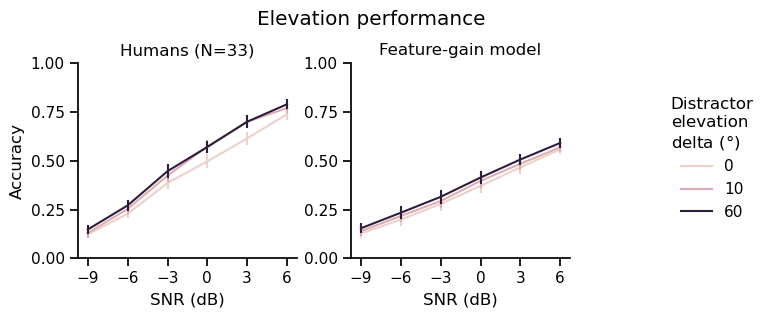

In [37]:
sns.set_context('notebook')

to_plot = merged_results[
                                        (merged_results.n_distractors == 2)
                                                #   & (merged_results.room_str == 'Min. reverb speaker array')
                                                & (merged_results.distractor_elev_delta.isin([0,10,60]))
                                                &	(merged_results.distractor_azim == 0) 
                                                &	(merged_results.target_elev != 0) 

                                                #   & (merged_results.snr.isin([6,3, 0, -3, -6, -9,]))
                                                    ].copy()

# to_plot.distractor_azim = to_plot.distractor_azim.abs()                    
# azim_results_for_thresh = to_plot.groupby(['model','room_str', 'distractor_azim', 'distractor_type', 'snr']).agg({'correct_mean':'mean'}).reset_index()



# azim_thresholds = []
# p0 = [0.0, -4, 4]
# for (model, room, dist_type, azim), group in azim_results_for_thresh.groupby(['model', 'room_str', 'distractor_type', 'distractor_azim']): #, 'gender_cond']):
#     thresh, fit_popt, _ = util_analysis.estimate_thresholds(group.snr.values, group.correct_mean.values, bounds_from_data=True)#, p0=p0)
#     if np.isnan(thresh):
#         print(f"Threshold is nan for azim {azim}")
#     azim_thresholds.append({'model': model, "room":room, "dist_type":dist_type, 'azim': azim, 'threshold':thresh}) #  'gender_cond':gend_cond,
        
# azim_thresh_df = pd.DataFrame(azim_thresholds)


plt.figure()
g = sns.relplot(data=to_plot[to_plot.snr.isin([6,3, 0, -3, -6, -9,])],
                                x='snr', y='correct_mean', hue="distractor_elev_delta",
                                kind='line', legend='full', facet_kws={"sharey":False, "sharex":False},
                                col='group', col_order=col_order,
                                # row='room_str',
                                # palette=palette, 
                                errorbar=('se', 1),
                                err_style='bars',
                                height=3, aspect=1)
g.set_axis_labels("SNR (dB)", "Accuracy")
# set legend title 
new_title = 'Distractor\nelevation\ndelta ($\degree$)'
g._legend.set_title(new_title)
# set xticks from -9 to 6
g.set(xticks=np.arange(-9, 7, 3), yticks=[0, 0.25, 0.5, 0.75, 1])
# column titles 
g.set_titles("{col_name}")
plt.suptitle(f'Elevation performance', y=1.05)


In [38]:
models_to_merge['azim_delta'] = (models_to_merge['distractor_azim'] - models_to_merge['target_azim']).abs()
models_to_merge['elev_delta'] = (models_to_merge['distractor_elev'] - models_to_merge['target_elev']).abs()

In [39]:
models_to_merge.model.unique()

array(['word_task_half_co_loc_v09_gender_bal_4M_w_no_cue_learned_higher_lr_less_dropout',
       'word_task_v09_4MGB_ln_first_arch_1',
       'word_task_v09_4MGB_ln_first_arch_2',
       'word_task_v09_4MGB_ln_first_arch_4',
       'word_task_v09_4MGB_ln_first_arch_6',
       'word_task_v09_4MGB_ln_first_arch_7',
       'word_task_v09_4MGB_ln_first_arch_8',
       'word_task_v09_4MGB_ln_first_arch_9'], dtype=object)

In [40]:
models_to_merge.room_str.unique()

array(['Min. reverb speaker array'], dtype=object)

In [41]:
models_to_merge[models_to_merge.room_str == 'Normal speaker array'].elev_delta.unique()

array([], dtype=int64)

In [42]:
### Get model thresholds and compare to human thresholds

# get thresholds for each model
## Bootstrap over participants to get average and confidence intervals over thresholds

np.random.seed(0)
n_boots = 1_000

N = models_to_merge.model.nunique()
for_thresh = models_to_merge[(models_to_merge.azim_delta.isin([0, 10, 60])) & (models_to_merge.elev_delta.isin([0, 10, 60])) ].copy()
thresholds = []
for (dist_azim, dist_elev), data in for_thresh.groupby(['azim_delta', 'elev_delta']):
    # break
    
    for _ in tqdm(range(n_boots)):
        # sample with replacement
        participant_sample = np.random.choice(data.model.unique(), size=N, replace=True)
        # stack sampled participants - this makes sure data is duplicated if resampled 
        sample_data = pd.concat([data[data.model == model] for model in participant_sample], axis=0, ignore_index=True).reset_index()
        # average participants per SNR 
        sample_data = sample_data.groupby(['snr']).agg({'correct_mean':'mean'}).reset_index()
        # fit to participant average
        thresh, poly= estimate_threshold_poly(sample_data.snr.values, sample_data.correct_mean.values, degree=3)
        thresholds.append({
                    'azim_delta':dist_azim, 'elev_delta':dist_elev,
                    'threshold':thresh})

model_thresh_df = pd.DataFrame(thresholds)


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

In [43]:
model_thresh_df_summary = model_thresh_df.groupby(['elev_delta', 'azim_delta', ]).agg({'threshold':['mean', 'std']}).reset_index()
# flatten multiindex
model_thresh_df_summary.columns = ['elev_delta', 'azim_delta', 'threshold', 'threshold_std']
model_thresh_df_summary
#

,elev_delta,azim_delta,threshold,threshold_std
0,0,0,4.152297,0.254451
1,0,10,-2.184108,0.219343
2,0,60,-6.695189,0.195548
3,10,0,3.681486,0.272636
4,60,0,2.953324,0.275140


Text(0.5, 1.0, 'Model thresholds')

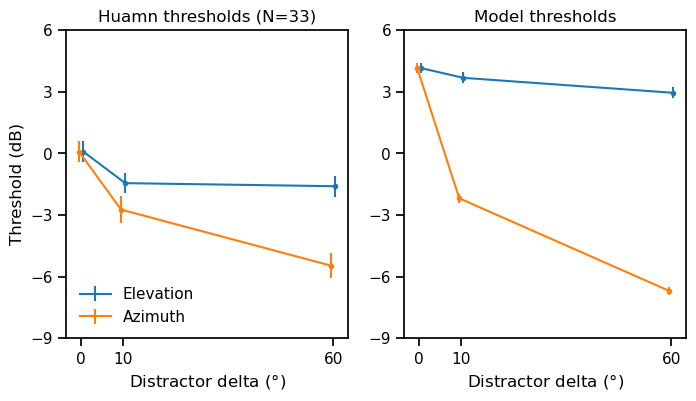

In [44]:
N = good_part_results.participant.nunique()
fig, axs = plt.subplots(1, 2, figsize=(8,4))
ax, model_ax = axs
elev_data = human_thresh_df_summary[human_thresh_df_summary.azim_delta == 0]
azim_data = human_thresh_df_summary[human_thresh_df_summary.elev_delta == 0]
ax.errorbar(data=elev_data, x=elev_data.elev_delta + 0.5, y='threshold', yerr='threshold_std', fmt='.-', label='Elevation')
ax.errorbar(data=azim_data, x=azim_data.azim_delta - 0.5, y='threshold', yerr='threshold_std', fmt='.-', label='Azimuth')

ax.legend(loc='lower left', markerscale=0)
ax.get_legend().get_frame().set_linewidth(0.0)

ax.set_xlabel('Distractor delta ($\degree$)')
ax.set_ylabel('Threshold (dB)')
ax.set_xticks([0, 10, 60])
ax.set_yticks(np.arange(-9, 7, 3));

ax.set_title(f"Huamn thresholds (N={N})")

# plot models results
model_elev_data = model_thresh_df_summary[(model_thresh_df_summary.azim_delta == 0)]
model_azim_data = model_thresh_df_summary[(model_thresh_df_summary.elev_delta == 0) & (model_thresh_df_summary.azim_delta.isin([0,10,60]))]
model_ax.errorbar(data=model_elev_data, x=model_elev_data.elev_delta + 0.5, y='threshold', yerr='threshold_std', fmt='.-', label='Elevation')
model_ax.errorbar(data=model_azim_data, x=model_azim_data.azim_delta - 0.5, y='threshold', yerr='threshold_std', fmt='.-', label='Azimuth')
model_ax.set_xlabel('Distractor delta ($\degree$)')
# model_ax.set_ylabel('Threshold (dB)')
model_ax.set_xticks([0, 10, 60])
model_ax.set_yticks(np.arange(-9, 7, 3));

model_ax.set_title(f"Model thresholds")

## Compare release in elevation  based on target elevation (top row is -20 degrees elevation, bottom row is 40 elevation)

<Figure size 640x480 with 0 Axes>

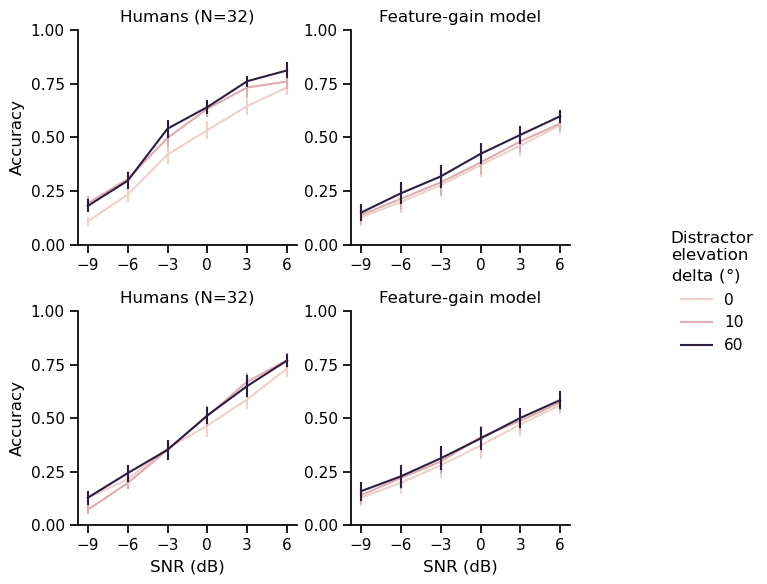

In [ ]:
sns.set_context('notebook')

to_plot = merged_results[
                                        (merged_results.n_distractors == 2)
                                                #   & (merged_results.room_str == 'Min. reverb speaker array')
                                                # & (merged_results.distractor_elev_delta.isin([0,10,60]))
                                                &	(merged_results.distractor_azim == 0) 
                                                &	(merged_results.target_elev != 0) 

                                                #   & (merged_results.snr.isin([6,3, 0, -3, -6, -9,]))
                                                    ].copy()

# to_plot.distractor_azim = to_plot.distractor_azim.abs()                    
# azim_results_for_thresh = to_plot.groupby(['model','room_str', 'distractor_azim', 'distractor_type', 'snr']).agg({'correct_mean':'mean'}).reset_index()



# azim_thresholds = []
# p0 = [0.0, -4, 4]
# for (model, room, dist_type, azim), group in azim_results_for_thresh.groupby(['model', 'room_str', 'distractor_type', 'distractor_azim']): #, 'gender_cond']):
#     thresh, fit_popt, _ = util_analysis.estimate_thresholds(group.snr.values, group.correct_mean.values, bounds_from_data=True)#, p0=p0)
#     if np.isnan(thresh):
#         print(f"Threshold is nan for azim {azim}")
#     azim_thresholds.append({'model': model, "room":room, "dist_type":dist_type, 'azim': azim, 'threshold':thresh}) #  'gender_cond':gend_cond,
        
# azim_thresh_df = pd.DataFrame(azim_thresholds)


plt.figure()
g = sns.relplot(data=to_plot[to_plot.snr.isin([6,3, 0, -3, -6, -9,])],
                                x='snr', y='correct_mean', hue="distractor_elev_delta",
                                kind='line', legend='full', facet_kws={"sharey":False, "sharex":False},
                                col='group', col_order=col_order,
                                row='target_elev',
                                # row='room_str',
                                # palette=palette, 
                                errorbar=('se', 1),
                                err_style='bars',
                                height=3, aspect=1)
g.set_axis_labels("SNR (dB)", "Accuracy")
# set legend title 
new_title = 'Distractor\nelevation\ndelta ($\degree$)'
g._legend.set_title(new_title)
# set xticks from -9 to 6
g.set(xticks=np.arange(-9, 7, 3), yticks=[0, 0.25, 0.5, 0.75, 1])
# column titles 
g.set_titles("{col_name}")
# plt.suptitle(f'Model elevation performance', y=1.05)

#### Just the model results 

<Figure size 640x480 with 0 Axes>

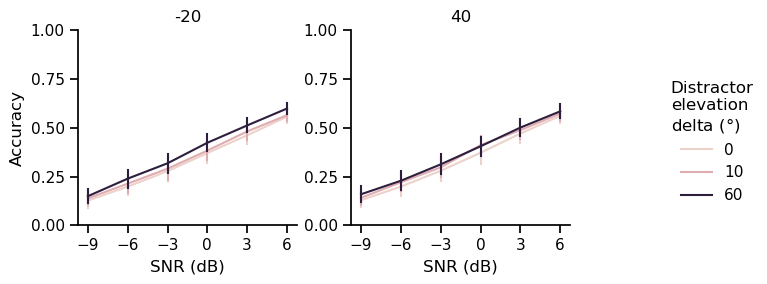

In [ ]:
to_plot = merged_results[
                    (merged_results.n_distractors == 2)
                    & (merged_results.group == 'Feature-gain model')
                        #   & (merged_results.room_str == 'Min. reverb speaker array')
                        # & (merged_results.distractor_elev_delta.isin([0,10,60]))
                    &	(merged_results.distractor_azim == 0) 
                    &	(merged_results.target_elev != 0) 

                        #   & (merged_results.snr.isin([6,3, 0, -3, -6, -9,]))
                          ].copy()

# to_plot.distractor_azim = to_plot.distractor_azim.abs()                    
# azim_results_for_thresh = to_plot.groupby(['model','room_str', 'distractor_azim', 'distractor_type', 'snr']).agg({'correct_mean':'mean'}).reset_index()



# azim_thresholds = []
# p0 = [0.0, -4, 4]
# for (model, room, dist_type, azim), group in azim_results_for_thresh.groupby(['model', 'room_str', 'distractor_type', 'distractor_azim']): #, 'gender_cond']):
#     thresh, fit_popt, _ = util_analysis.estimate_thresholds(group.snr.values, group.correct_mean.values, bounds_from_data=True)#, p0=p0)
#     if np.isnan(thresh):
#         print(f"Threshold is nan for azim {azim}")
#     azim_thresholds.append({'model': model, "room":room, "dist_type":dist_type, 'azim': azim, 'threshold':thresh}) #  'gender_cond':gend_cond,
    
# azim_thresh_df = pd.DataFrame(azim_thresholds)


plt.figure()
g = sns.relplot(data=to_plot[to_plot.snr.isin([6,3, 0, -3, -6, -9,])],
                x='snr', y='correct_mean', hue="distractor_elev_delta",
                kind='line', legend='full', facet_kws={"sharey":False, "sharex":False},
                col='target_elev', 
                # row='room_str',
                # palette=palette, 
                errorbar=('se', 1),
                err_style='bars',
                height=3, aspect=1)
g.set_axis_labels("SNR (dB)", "Accuracy")
# set legend title 
new_title = 'Distractor\nelevation\ndelta ($\degree$)'
g._legend.set_title(new_title)
# set xticks from -9 to 6
g.set(xticks=np.arange(-9, 7, 3), yticks=[0, 0.25, 0.5, 0.75, 1])
# column titles 
g.set_titles("{col_name}")
# plt.suptitle(f'Model elevation performance', y=1.05)

#### Just the human results 

<Figure size 640x480 with 0 Axes>

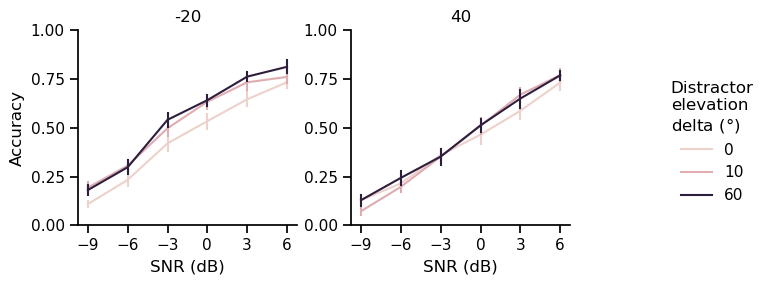

In [ ]:
to_plot = merged_results[
                                        (merged_results.n_distractors == 2)
                                        & (merged_results.group.str.contains('Human'))
                                                #   & (merged_results.room_str == 'Min. reverb speaker array')
                                                # & (merged_results.distractor_elev_delta.isin([0,10,60]))
                                                &	(merged_results.distractor_azim == 0) 
                                                &	(merged_results.target_elev != 0) 

                                                #   & (merged_results.snr.isin([6,3, 0, -3, -6, -9,]))
                                                    ].copy()

# to_plot.distractor_azim = to_plot.distractor_azim.abs()                    
# azim_results_for_thresh = to_plot.groupby(['model','room_str', 'distractor_azim', 'distractor_type', 'snr']).agg({'correct_mean':'mean'}).reset_index()



# azim_thresholds = []
# p0 = [0.0, -4, 4]
# for (model, room, dist_type, azim), group in azim_results_for_thresh.groupby(['model', 'room_str', 'distractor_type', 'distractor_azim']): #, 'gender_cond']):
#     thresh, fit_popt, _ = util_analysis.estimate_thresholds(group.snr.values, group.correct_mean.values, bounds_from_data=True)#, p0=p0)
#     if np.isnan(thresh):
#         print(f"Threshold is nan for azim {azim}")
#     azim_thresholds.append({'model': model, "room":room, "dist_type":dist_type, 'azim': azim, 'threshold':thresh}) #  'gender_cond':gend_cond,
        
# azim_thresh_df = pd.DataFrame(azim_thresholds)


plt.figure()
g = sns.relplot(data=to_plot[to_plot.snr.isin([6,3, 0, -3, -6, -9,])],
                                x='snr', y='correct_mean', hue="distractor_elev_delta",
                                kind='line', legend='full', facet_kws={"sharey":False, "sharex":False},
                                col='target_elev', 
                                # row='room_str',
                                # palette=palette, 
                                errorbar=('se', 1),
                                err_style='bars',
                                height=3, aspect=1)
g.set_axis_labels("SNR (dB)", "Accuracy")
# set legend title 
new_title = 'Distractor\nelevation\ndelta ($\degree$)'
g._legend.set_title(new_title)
# set xticks from -9 to 6
g.set(xticks=np.arange(-9, 7, 3), yticks=[0, 0.25, 0.5, 0.75, 1])
# column titles 
g.set_titles("{col_name}")
# plt.suptitle(f'Model elevation performance', y=1.05)

<Figure size 640x480 with 0 Axes>

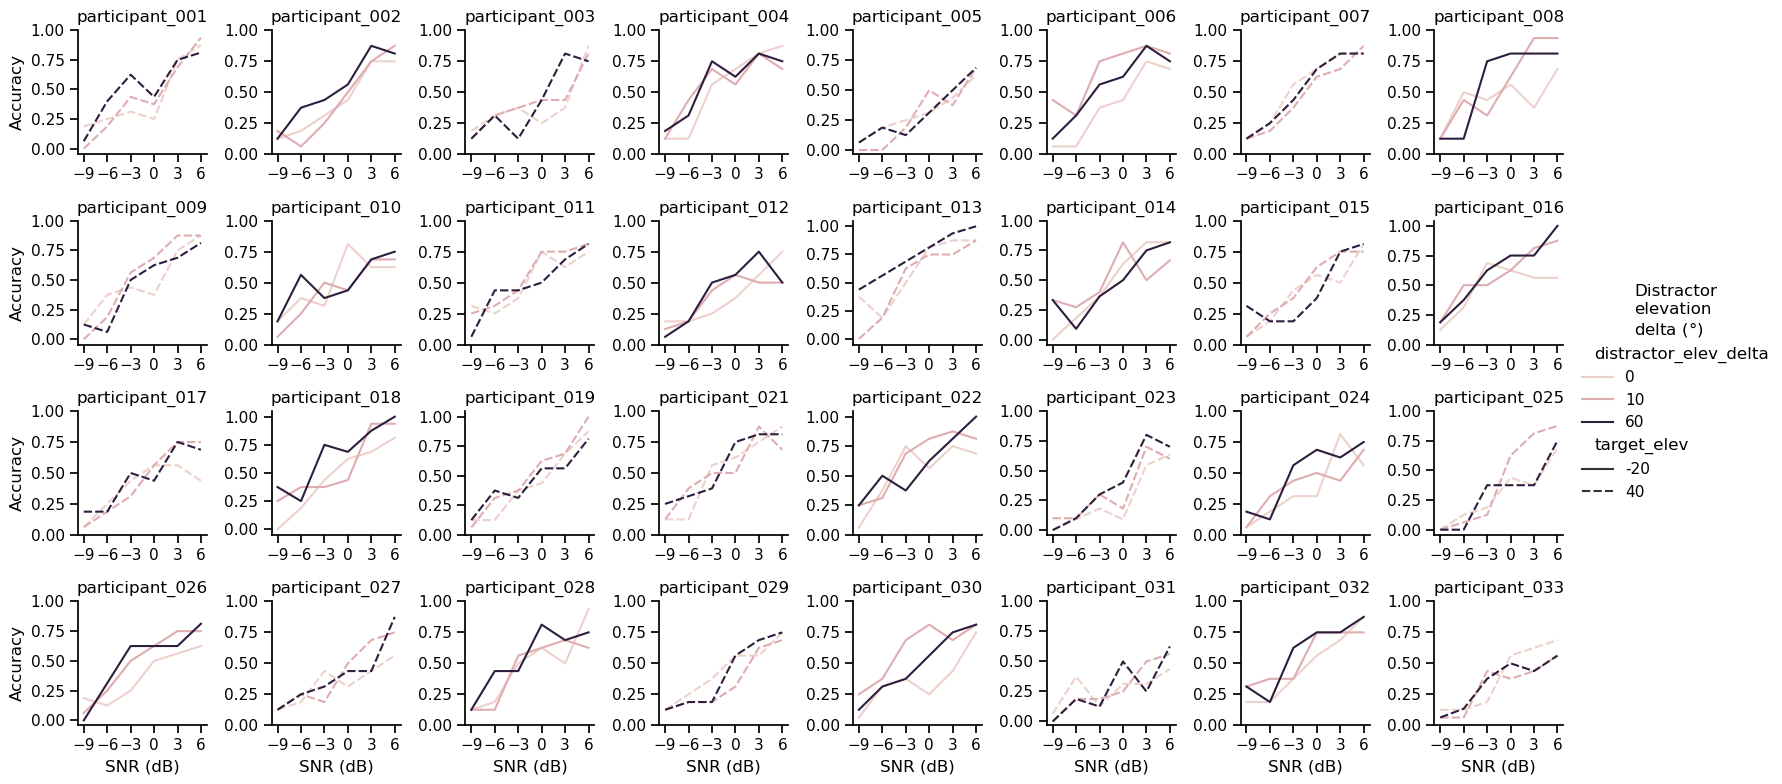

In [ ]:
to_plot = merged_results[
                                        (merged_results.n_distractors == 2)
                                        & (merged_results.group.str.contains('Human'))
                                                #   & (merged_results.room_str == 'Min. reverb speaker array')
                                                # & (merged_results.distractor_elev_delta.isin([0,10,60]))
                                                &	(merged_results.distractor_azim == 0) 
                                                &	(merged_results.target_elev != 0) 

                                                #   & (merged_results.snr.isin([6,3, 0, -3, -6, -9,]))
                                                    ].copy()

# to_plot.distractor_azim = to_plot.distractor_azim.abs()                    
# azim_results_for_thresh = to_plot.groupby(['model','room_str', 'distractor_azim', 'distractor_type', 'snr']).agg({'correct_mean':'mean'}).reset_index()



# azim_thresholds = []
# p0 = [0.0, -4, 4]
# for (model, room, dist_type, azim), group in azim_results_for_thresh.groupby(['model', 'room_str', 'distractor_type', 'distractor_azim']): #, 'gender_cond']):
#     thresh, fit_popt, _ = util_analysis.estimate_thresholds(group.snr.values, group.correct_mean.values, bounds_from_data=True)#, p0=p0)
#     if np.isnan(thresh):
#         print(f"Threshold is nan for azim {azim}")
#     azim_thresholds.append({'model': model, "room":room, "dist_type":dist_type, 'azim': azim, 'threshold':thresh}) #  'gender_cond':gend_cond,
        
# azim_thresh_df = pd.DataFrame(azim_thresholds)


plt.figure()
g = sns.relplot(data=to_plot[to_plot.snr.isin([6,3, 0, -3, -6, -9,])],
                                x='snr', y='correct_mean', hue="distractor_elev_delta",
                                kind='line', legend='full', facet_kws={"sharey":False, "sharex":False},
                                col='participant', col_wrap=8,
                                # row='room_str',
                                # palette=palette, 
                                style='target_elev',
                                errorbar=('se', 1),
                                err_style='bars',
                                height=2, aspect=1)
g.set_axis_labels("SNR (dB)", "Accuracy")
# set legend title 
new_title = 'Distractor\nelevation\ndelta ($\degree$)'
g._legend.set_title(new_title)
# set xticks from -9 to 6
g.set(xticks=np.arange(-9, 7, 3), yticks=[0, 0.25, 0.5, 0.75, 1])
# column titles 
g.set_titles("{col_name}")
# plt.suptitle(f'Model elevation performance', y=1.05)

#### Old tests for ref code - not used in this analysis 

In [ ]:
### Basic paired t-test (measure if observed difference is greater than 0)
np.percentile(diff_of_diff_10_dist, [2.5,97.5]), np.percentile(diff_of_diff_60_dist, [2.5,97.5])


from scipy.stats import ttest_rel # import paired t-test

np.random.seed(0)
## Run paired ttest between conditions

to_run = good_part_results[(good_part_results.distractor_azim_delta == 0)].copy()

zero_delta = to_run[(to_run.distractor_elev_delta == 0)].groupby(['participant','snr']).agg({'correct_mean':'mean'}).reset_index()
ten_delta = to_run[(to_run.distractor_elev_delta == 10)].groupby(['participant','snr']).agg({'correct_mean':'mean'}).reset_index()
sixty_delta = to_run[(to_run.distractor_elev_delta == 60)].groupby(['participant','snr']).agg({'correct_mean':'mean'}).reset_index()


n_snrs = good_part_results.snr.nunique()
ttest_results = np.zeros((n_snrs, 3, 2))
for i, snr in enumerate(good_part_results.snr.unique()):
    # compute ttest for each snr
    zero_delta_snr = zero_delta[zero_delta.snr == snr].correct_mean.values
    ten_delta_snr = ten_delta[ten_delta.snr == snr].correct_mean.values
    sixty_delta_snr = sixty_delta[sixty_delta.snr == snr].correct_mean.values

    ttest_results[i, 0, :] = ttest_rel(zero_delta_snr, ten_delta_snr)
    ttest_results[i, 1, :] = ttest_rel(zero_delta_snr, sixty_delta_snr)
    ttest_results[i, 2, :] = ttest_rel(ten_delta_snr, sixty_delta_snr)
    


# plot results per snr  
p_vals = ttest_results[:, :, 1]

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
sns.heatmap(np.flipud(p_vals), annot=True, ax=ax,
           xticklabels=['$0^\circ$ vs $10^\circ$', '$0^\circ$ vs $60^\circ$', '$10^\circ$ vs $60^\circ$'],
           yticklabels=good_part_results.snr.unique()[::-1],
           cmap='viridis_r')
ax.set_title('Paired T-test p-values');
ax.set_xlabel('Elevation deltas')
ax.set_ylabel('SNR')
# label colorbar
cbar = ax.collections[0].colorbar
cbar.set_label('p-value')
plt.tight_layout()

### More elaborate permutation test

np.random.seed(0)
## Proceedure: Generate null distribution, then compute p-value for each SNR level.
# Sample trials per participant first, then group. 
# Use the same number of trials for each group.
# Compare the means of the two groups.
# Repeat 10,000 times.
# Compute stat per SNR level individually.

# Only look at trials in elevation conditions 
to_run_stats = good_part_results[(good_part_results.distractor_azim == 0) & (good_part_results.target_azim == 0)].copy()


## compute actual differences 
true_delta_at_10 = (to_run_stats[to_run_stats.distractor_elev_delta == 10].groupby(['snr']).correct_mean.mean() - to_run_stats[to_run_stats.distractor_elev_delta == 0].groupby(['snr']).correct_mean.mean()).values
true_delta_at_60 = (to_run_stats[to_run_stats.distractor_elev_delta == 60].groupby(['snr']).correct_mean.mean() - to_run_stats[to_run_stats.distractor_elev_delta == 0].groupby(['snr']).correct_mean.mean()).values

n_permutations = 10_000
n_snrs = 6 

delta_10_results = np.zeros((n_permutations, n_snrs))
delta_60_results = np.zeros((n_permutations, n_snrs))

for i in tqdm(range(n_permutations)):
    # Randomly sample trails per participant with replacement, then summarize
    perm_data = good_part_results.copy()
    # randomly permute elevation assignment 
    perm_data['distractor_elev_delta'] = np.random.permutation(perm_data.distractor_elev_delta.values)
    # sumarize_differences
    perm_data = perm_data.groupby(['participant', 'distractor_elev_delta', 'snr']).agg({'correct_mean':'mean'}).reset_index()

    delta_10_results[i, :] = perm_data[perm_data.distractor_elev_delta == 10].groupby(['snr']).correct_mean.mean() - perm_data[perm_data.distractor_elev_delta == 0].groupby(['snr']).correct_mean.mean()
    delta_60_results[i, :] = perm_data[perm_data.distractor_elev_delta == 60].groupby(['snr']).correct_mean.mean() - perm_data[perm_data.distractor_elev_delta == 0].groupby(['snr']).correct_mean.mean()



# get p value from permutation test
p_value_10 = (np.abs(delta_10_results) > true_delta_at_10).sum(0) / n_permutations
p_value_60 = (np.abs(delta_60_results) > true_delta_at_60).sum(0) / n_permutations

print(f"p value for 10 degree difference: {p_value_10}")
print(f"p value for 60 degree difference: {p_value_60}")

# plot results per snr
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

data = np.stack([p_value_10, p_value_60], axis=1)
sns.heatmap(np.flipud(data), annot=True, ax=ax,
           xticklabels=['$0^\circ$ vs $10^\circ$', '$0^\circ$ vs $60^\circ$'],
           yticklabels=good_part_results.snr.unique()[::-1],
           cmap='viridis_r')
ax.set_title('Permutation test p-values');
ax.set_xlabel('Elevation deltas')
ax.set_ylabel('SNR')
# label colorbar
cbar = ax.collections[0].colorbar
cbar.set_label('p-value')
plt.tight_layout()

### Threshold estimate proceedure

Will be plotting grand average thresholds:
1) average participant data per condition
2) fit thresholds to averaged data
3) bootstrap over participants for error bars 

Actual implementation will use pandas and seaborn to plot average, just need to save individual bootstraps


good_part_results
###### Sanity check that per-participant fits are worse than bootstrapped fits 

thresholds = []
for (participant, target_azim, target_elev, dist_azim, dist_elev), group in good_part_results.groupby(['participant', 'target_azim', 'target_elev', 'azim_delta', 'elev_delta']): #, 'gender_cond']):
    try:
        thresh, _ = estimate_threshold_poly(group.snr.values, group.correct_mean.values, degree=2)
    except:
        thresh = np.nan

    if np.isnan(thresh):
        print(f"Threshold is nan for {participant}, {target_azim}, {target_elev}, {dist_azim}, {dist_elev}")

    thresholds.append({'participant':participant, 'target_azim':target_azim, 'target_elev':target_elev, 
                    'azim_delta':dist_azim, 'elev_delta':dist_elev, 'threshold':thresh}) #  'gender_cond':gend_cond,

human_thresh_df = pd.DataFrame(thresholds)


to_plot = human_thresh_df[(human_thresh_df.elev_delta == 0 )].copy()

# sns.set_context('notebook')
## Clip for plotting 
# human_thresh_df.loc[human_thresh_df['threshold'] < -10, 'threshold'] = -10
# human_thresh_df.loc[human_thresh_df['threshold'] > 0, 'threshold'] = 0
# to_plot['azim_delta'] = to_plot.dist_azim.abs()

g = sns.relplot(data=to_plot, x='azim_delta', y='threshold', kind='line',
                # hue='gender_cond',
                # style='room_ix',
                # error_ba
                color='tab:orange',
                err_style='bars',
                errorbar=('se',1),
                height=4, aspect=1)
# update legend 
for part_name, part_data in to_plot.groupby(['participant']):
    sns.lineplot(data=part_data, x='azim_delta', y='threshold', color='grey', alpha=0.5, ax=g.ax)


g.set_axis_labels("Distractor azimuth ($\degree$, +/-)", "Threshold TMR (dB)")
g.set(yticks=np.arange(-10,1,2) , xticks=[0, 10, 60])
ratio = 1 
for ax in g.axes.flat:
    xleft, xright = ax.get_xlim()
    ybottom, ytop = ax.get_ylim()
    ax.set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(1.5)
        

g = sns.relplot(data=to_plot, x='azim_delta', y='threshold', kind='line',
                # hue='gender_cond',
                col='target_elev',
                err_style='bars',
                errorbar=('se', 2),
                # style='room_ix',
                height=3.5, aspect=1)
# update legend 

g.set_axis_labels("Distractor azimuth ($\degree$, +/-)", "Threshold TMR (dB)")
g.set(yticks=np.arange(-10,1,2) , xticks=[0, 10, 60])
ratio = 1 
for ax in g.axes.flat:
    xleft, xright = ax.get_xlim()
    ybottom, ytop = ax.get_ylim()
    ax.set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(1.5)
human_thresh_df[ (human_thresh_df.azim_delta == 0 )].groupby(['elev_delta']).threshold.sem()
#### Manually plot. 

fig, ax = plt.subplots(1, 1, figsize=(4, 4))
# compute mean and sem for each condition 
elev_conds = human_thresh_df[ (human_thresh_df.azim_delta == 0 )].groupby(['elev_delta']).agg({'threshold':['mean', 'sem']}).reset_index()
azim_conds = human_thresh_df[ (human_thresh_df.elev_delta == 0)].groupby(['azim_delta']).agg({'threshold':['mean', 'sem']}).reset_index()
N = human_thresh_df.participant.nunique()
deltas = human_thresh_df.elev_delta.unique()


ax.errorbar(deltas, elev_conds.threshold['mean'], yerr=elev_conds.threshold['sem'], label="Elevation", fmt='o-', color='tab:blue')
ax.errorbar(deltas, azim_conds.threshold['mean'], yerr=azim_conds.threshold['sem'], label="Azimuth", fmt='o-', color='tab:orange')
ax.set_xlabel('Distractor delta ($\degree$)')

means
#### Manually plot. 

fig, ax = plt.subplots(1, 1, figsize=(4, 4))
# compute mean and sem for each condition 
elev_to_plot = human_thresh_df[ (human_thresh_df.azim_delta == 0 )].copy()
azim_to_plot = human_thresh_df[ (human_thresh_df.elev_delta == 0 )].copy()

N = elev_to_plot.participant.nunique()
deltas = elev_to_plot.elev_delta.unique()
elev_means, elev_errors = [], []
azim_means, azim_errors = [], []

for delta in deltas:
    data = elev_to_plot[elev_to_plot.elev_delta == delta].threshold.values 
    mean = np.nanmean(data)
    sem = np.nanstd(data) / np.sqrt(N)
    elev_means.append(mean)
    elev_errors.append(sem)
    azim_data = azim_to_plot[azim_to_plot.azim_delta == delta].threshold.values
    azim_mean = np.nanmean(azim_data)
    azim_sem = np.nanstd(azim_data) / np.sqrt(N)
    azim_means.append(azim_mean)
    azim_errors.append(azim_sem)

    
ax.errorbar(deltas, elev_means, yerr=elev_errors, label=f"Elevation")
ax.errorbar(deltas, azim_means, yerr=azim_errors, label=f"Azimuth")
to_plot = human_thresh_df[ (human_thresh_df.azim_delta == 0 )].copy().dropna()
# to_plot['elev_delta'] = (to_plot['target_elev'] - to_plot['dist_elev']).abs()

g = sns.relplot(data=to_plot, x='elev_delta', y='threshold', kind='line',
                # hue='gender_cond',
                # style='room_ix',
                color='tab:cyan',

                err_style='bars',
                errorbar=('pi', 68),
                height=4, aspect=1)
# update legend 
for part_name, part_data in to_plot.groupby(['participant']):
    sns.lineplot(data=part_data, x='elev_delta', y='threshold', color='grey', alpha=0.5, ax=g.ax)



g.set_axis_labels("Elevation delta ($\degree$)", "Threshold TMR (dB)")
g.set(yticks=np.arange(-10,1,2) , xticks=[0, 10, 60])
ratio = 1 
for ax in g.axes.flat:
    xleft, xright = ax.get_xlim()
    ybottom, ytop = ax.get_ylim()
    ax.set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(1.5)
        
g = sns.relplot(data=to_plot, x='elev_delta', y='threshold', kind='line',
                # hue='gender_cond',
                col='target_elev',
                err_style='bars',
                errorbar=('se', 2),
                # style='room_ix',
                height=3.5, aspect=1)
# update legend 

g.set_axis_labels("Elevation delta ($\degree$)", "Threshold TMR (dB)")
g.set(yticks=np.arange(-9,1,3) , xticks=[0, 10, 60])
ratio = 1 
for ax in g.axes.flat:
    xleft, xright = ax.get_xlim()
    ybottom, ytop = ax.get_ylim()
    ax.set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(1.5)